
# Sesión 02 — Modelos de Clasificación
**Ingeniería del Conocimiento (ISO56B)** · UNCP · 2026-II

**Docente:** Msc. Jaime Antonio Huaytalla Pariona

**Dataset:** Breast Cancer Wisconsin (569 muestras, 30 features, clasificación binaria)

---

## 1. Configuración del entorno

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, roc_curve, auc,
    ConfusionMatrixDisplay, RocCurveDisplay
)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('✓ Librerías cargadas correctamente')

✓ Librerías cargadas correctamente


---
## 2. Carga y exploración del dataset

El dataset **Breast Cancer Wisconsin** contiene 569 muestras de biopsias de mama con 30 features numéricas computadas a partir de imágenes digitalizadas de aspiración con aguja fina (FNA). El target es binario: **maligno (0)** o **benigno (1)**.

In [4]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['diagnosis'] = df['target'].map({0: 'maligno', 1: 'benigno'})

print(f'Dataset: {df.shape[0]} muestras, {df.shape[1]-2} features')
print(f'\nDistribución de clases:')
print(df['diagnosis'].value_counts())
print(f'\nProporción: {df["target"].mean():.1%} benigno, {1-df["target"].mean():.1%} maligno')

Dataset: 569 muestras, 30 features

Distribución de clases:
diagnosis
benigno    357
maligno    212
Name: count, dtype: int64

Proporción: 62.7% benigno, 37.3% maligno


In [ ]:
df.describe().round(3)

---
## 3. Análisis exploratorio orientado a clasificación

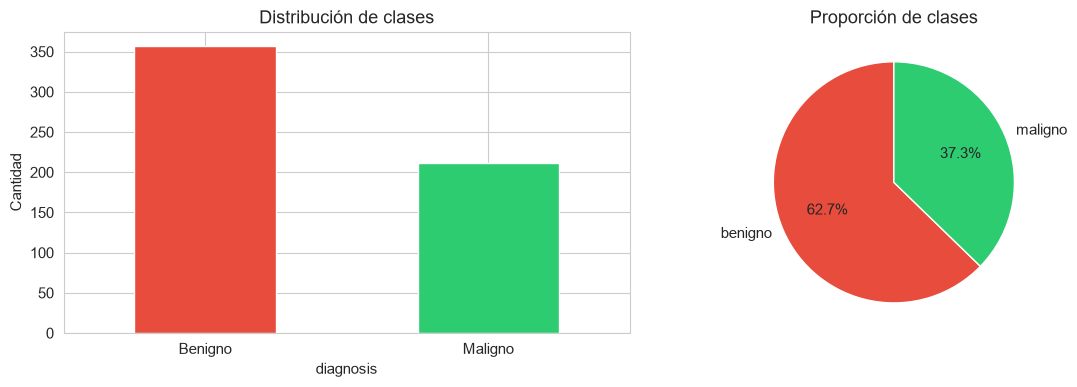

In [5]:
# 3.1  Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
colors = ['#e74c3c', '#2ecc71']
df['diagnosis'].value_counts().plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Distribución de clases')
axes[0].set_ylabel('Cantidad')
axes[0].set_xticklabels(['Benigno', 'Maligno'], rotation=0)

# Pie chart
df['diagnosis'].value_counts().plot(kind='pie', ax=axes[1], colors=colors,
    autopct='%1.1f%%', startangle=90)
axes[1].set_ylabel('')
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

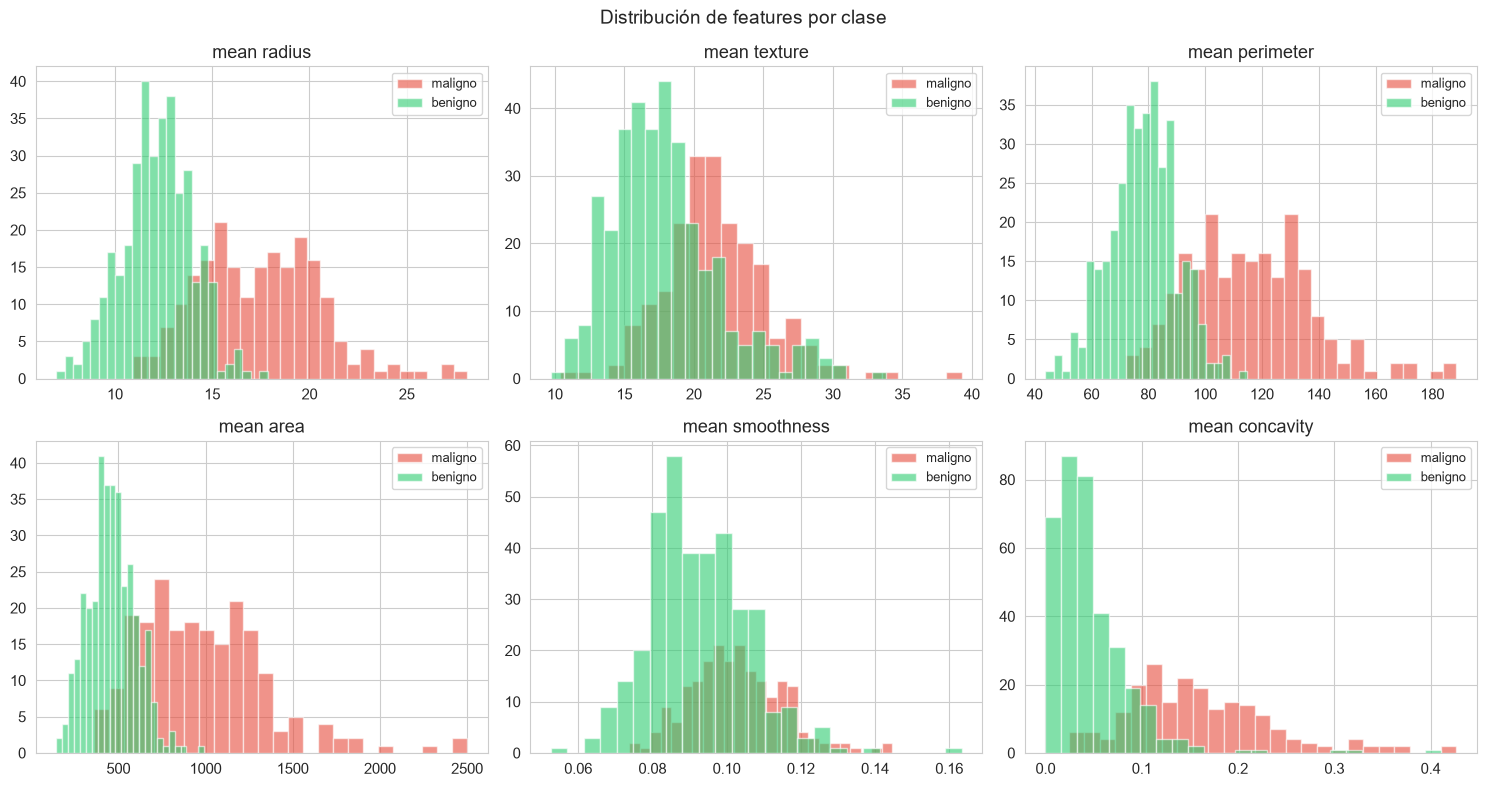

In [6]:
# 3.2  Distribución de features clave por clase
key_features = ['mean radius', 'mean texture', 'mean perimeter',
                'mean area', 'mean smoothness', 'mean concavity']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, feat in enumerate(key_features):
    ax = axes[i//3, i%3]
    for label, color in zip([0, 1], colors):
        subset = df[df['target'] == label][feat]
        ax.hist(subset, bins=25, alpha=0.6, color=color,
                label='maligno' if label == 0 else 'benigno')
    ax.set_title(feat)
    ax.legend(fontsize=9)

plt.suptitle('Distribución de features por clase', fontsize=14)
plt.tight_layout()
plt.show()

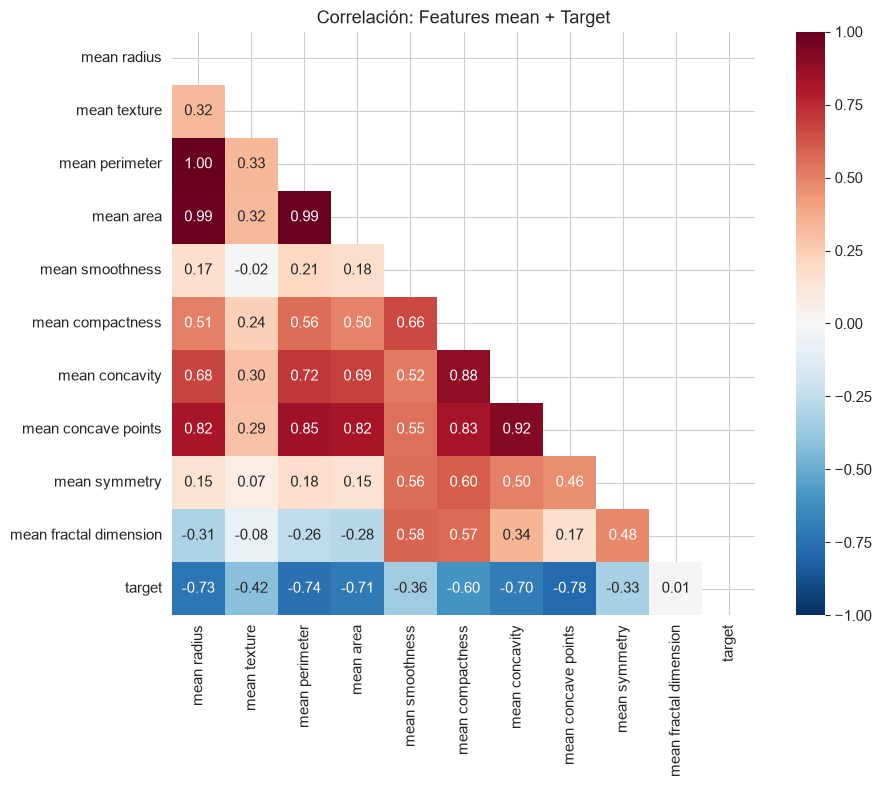

In [8]:
# 3.3  Matriz de correlación (features mean)
mean_features = [c for c in df.columns if 'mean' in c]
plt.figure(figsize=(10, 8))
corr = df[mean_features + ['target']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True)
plt.title('Correlación: Features mean + Target')
plt.tight_layout()
plt.show()

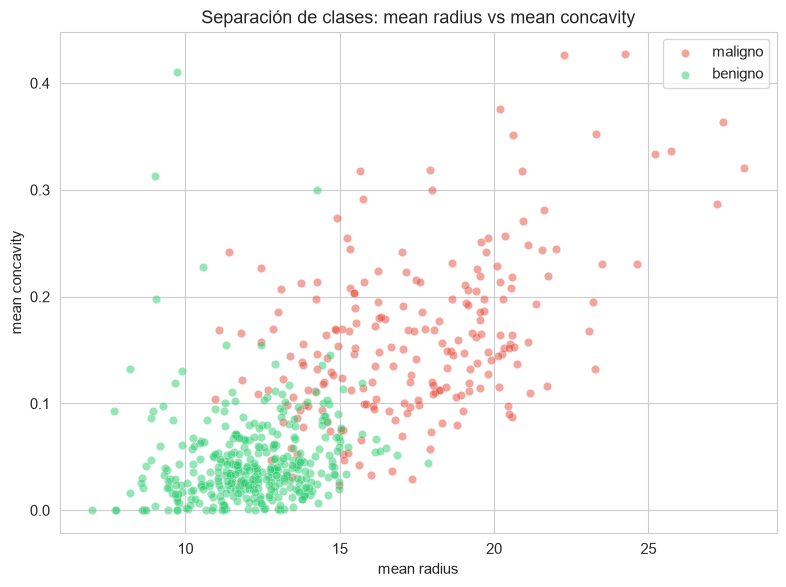

In [9]:
# 3.4  Scatter plot: 2 features más discriminativas
fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in zip([0, 1], colors, ['maligno', 'benigno']):
    mask = df['target'] == label
    ax.scatter(df.loc[mask, 'mean radius'], df.loc[mask, 'mean concavity'],
              alpha=0.5, c=color, label=name, edgecolors='w', linewidth=0.3)
ax.set_xlabel('mean radius')
ax.set_ylabel('mean concavity')
ax.set_title('Separación de clases: mean radius vs mean concavity')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Preparación de datos

In [10]:
X = df[data.feature_names].copy()
y = df['target'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Test:          {X_test.shape[0]} muestras')
print(f'\nProporción en train: {y_train.mean():.1%} benigno')
print(f'Proporción en test:  {y_test.mean():.1%} benigno')

# Stratified K-Fold para validación cruzada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Entrenamiento: 455 muestras
Test:          114 muestras

Proporción en train: 62.6% benigno
Proporción en test:  63.2% benigno


### Funciones auxiliares para evaluación de clasificadores

In [11]:
def eval_classifier(model, X_tr, y_tr, X_te, y_te, model_name='Modelo'):
    """Evalúa un clasificador: métricas, matriz de confusión y reporte."""
    y_pred = model.predict(X_te)
    
    metrics = {
        'Accuracy':  accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall':    recall_score(y_te, y_pred),
        'F1-Score':  f1_score(y_te, y_pred)
    }
    
    print(f'=== {model_name} ===')
    for k, v in metrics.items():
        print(f'  {k}: {v:.4f}')
    
    # Matriz de confusión
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Maligno', 'Benigno'],
                yticklabels=['Maligno', 'Benigno'])
    axes[0].set_title(f'Matriz de Confusión — {model_name}')
    axes[0].set_xlabel('Predicción')
    axes[0].set_ylabel('Real')
    
    # Desglose FP y FN
    tn, fp, fn, tp = cm.ravel()
    labels = ['TN\n(benigno\ncorrecto)', 'FP\n(benigno→\nmaligno)',
              'FN\n(maligno→\nbenigno)', 'TP\n(maligno\ncorrecto)']
    values = [tn, fp, fn, tp]
    bar_colors = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db']
    axes[1].bar(labels, values, color=bar_colors)
    axes[1].set_title(f'Desglose — {model_name}')
    axes[1].set_ylabel('Cantidad')
    
    plt.tight_layout()
    plt.show()
    
    print(f'\n  FN (maligno no detectado): {fn}')
    print(f'  FP (benigno como maligno): {fp}')
    print(f'\nReporte completo:')
    print(classification_report(y_te, y_pred,
          target_names=['maligno', 'benigno']))
    
    return metrics


def plot_roc(model, X_te, y_te, model_name='Modelo', ax=None):
    """Genera la curva ROC de un modelo."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_te)
    else:
        print(f'{model_name}: no soporta probabilidades')
        return None
    
    fpr, tpr, _ = roc_curve(y_te, y_score)
    roc_auc = auc(fpr, tpr)
    
    ax.plot(fpr, tpr, linewidth=2,
            label=f'{model_name} (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
    ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    ax.set_title(f'Curva ROC — {model_name}')
    ax.legend()
    
    return roc_auc

---
## 5. Modelo 1 — Regresión Logística

**Fundamento:** Modelo lineal que estima P(y=1|x) mediante la función sigmoide σ(z) = 1/(1+e^(−z)). La frontera de decisión es lineal en el espacio de features. Se optimiza minimizando la Log-Loss (entropía cruzada binaria) con regularización L2 por defecto.

In [12]:
# 5.1  Pipeline con estandarización
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Validación cruzada estratificada
cv_lr = cross_validate(pipe_lr, X_train, y_train, cv=skf,
                       scoring=['accuracy', 'f1', 'recall'],
                       return_train_score=True)

print('Regresión Logística — Cross-Validation (5-fold)')
print(f'  Accuracy:  {cv_lr["test_accuracy"].mean():.4f} ± {cv_lr["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_lr["test_f1"].mean():.4f} ± {cv_lr["test_f1"].std():.4f}')
print(f'  Recall:    {cv_lr["test_recall"].mean():.4f} ± {cv_lr["test_recall"].std():.4f}')

# Entrenar modelo final
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

Regresión Logística — Cross-Validation (5-fold)
  Accuracy:  0.9780 ± 0.0098
  F1-Score:  0.9825 ± 0.0078
  Recall:    0.9860 ± 0.0131


=== Regresión Logística ===
  Accuracy: 0.9825
  Precision: 0.9861
  Recall: 0.9861
  F1-Score: 0.9861


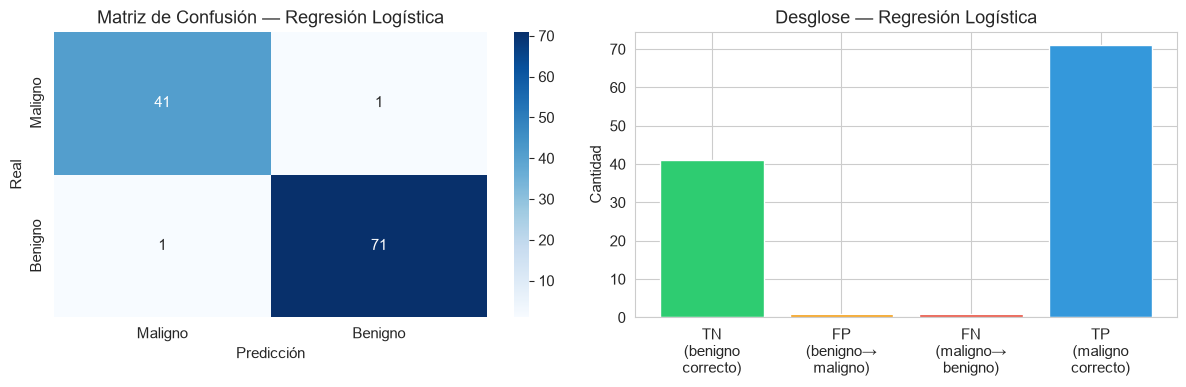


  FN (maligno no detectado): 1
  FP (benigno como maligno): 1

Reporte completo:
              precision    recall  f1-score   support

     maligno       0.98      0.98      0.98        42
     benigno       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [13]:
# 5.2  Evaluación completa
metrics_lr = eval_classifier(pipe_lr, X_train, y_train, X_test, y_test,
                             'Regresión Logística')

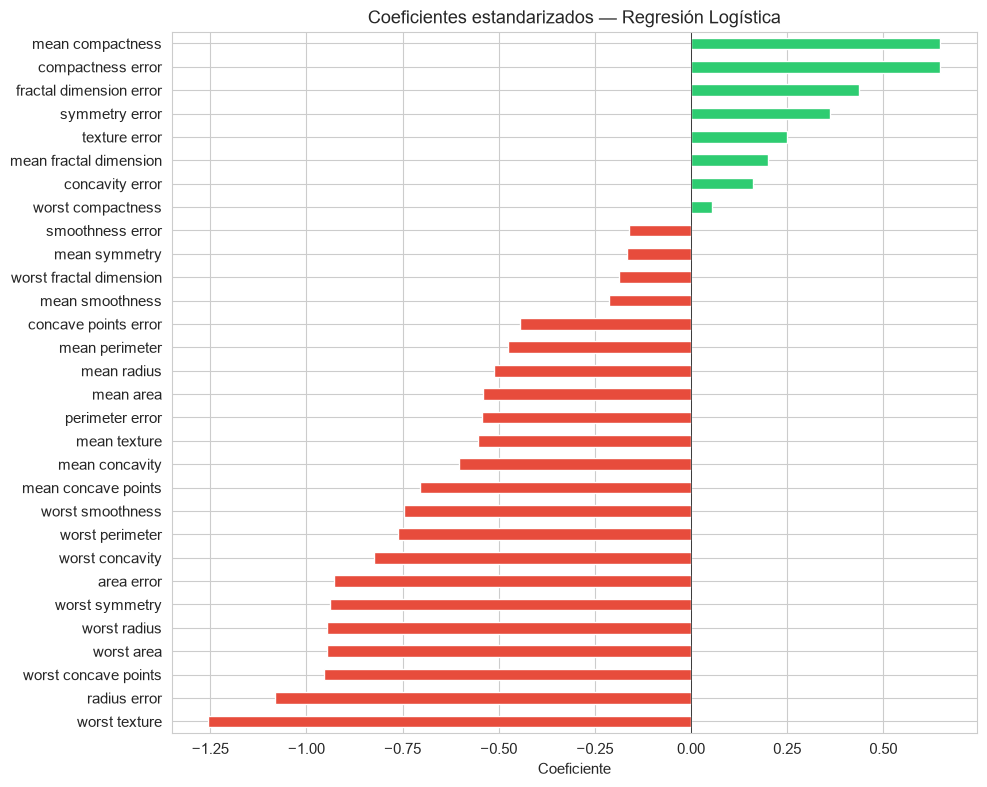

Interpretación:
  → Features que más indican MALIGNO: ['worst texture', 'radius error', 'worst concave points']
  → Features que más indican BENIGNO: ['fractal dimension error', 'compactness error', 'mean compactness']


In [14]:
# 5.3  Coeficientes estandarizados
coefs = pd.Series(
    pipe_lr.named_steps['clf'].coef_[0],
    index=data.feature_names
).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors_bar = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefs]
coefs.plot(kind='barh', ax=ax, color=colors_bar)
ax.set_title('Coeficientes estandarizados — Regresión Logística')
ax.set_xlabel('Coeficiente')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('Interpretación:')
print(f'  → Features que más indican MALIGNO: {coefs.head(3).index.tolist()}')
print(f'  → Features que más indican BENIGNO: {coefs.tail(3).index.tolist()}')

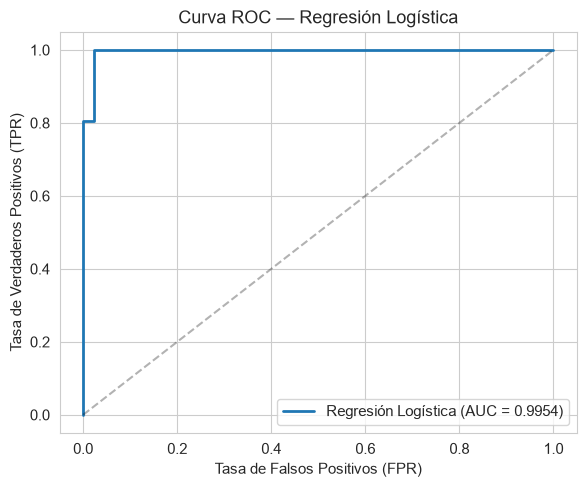

AUC: 0.9954


In [15]:
# 5.4  Curva ROC
fig, ax = plt.subplots(figsize=(6, 5))
auc_lr = plot_roc(pipe_lr, X_test, y_test, 'Regresión Logística', ax)
plt.tight_layout()
plt.show()
print(f'AUC: {auc_lr:.4f}')

---
## 6. Modelo 2 — Árbol de Decisión

**Fundamento:** CART construye particiones recursivas del espacio de features. En cada nodo selecciona la feature y el umbral que maximizan la reducción de impureza (Gini: G(t) = 1 − Σpₖ²). Las particiones son ortogonales a los ejes.

In [16]:
# 6.1  Árbol sin restricciones (para mostrar sobreajuste)
pipe_dt_full = Pipeline([
    ('clf', DecisionTreeClassifier(random_state=42))
])

cv_dt_full = cross_validate(pipe_dt_full, X_train, y_train, cv=skf,
                            scoring=['accuracy', 'f1', 'recall'],
                            return_train_score=True)

print('Árbol de Decisión (SIN restricciones) — CV 5-fold')
print(f'  Train Accuracy: {cv_dt_full["train_accuracy"].mean():.4f}')
print(f'  Test Accuracy:  {cv_dt_full["test_accuracy"].mean():.4f} ± {cv_dt_full["test_accuracy"].std():.4f}')
print(f'  Test F1-Score:  {cv_dt_full["test_f1"].mean():.4f} ± {cv_dt_full["test_f1"].std():.4f}')
print(f'\n⚠ Train accuracy ~1.0 indica sobreajuste')

Árbol de Decisión (SIN restricciones) — CV 5-fold
  Train Accuracy: 1.0000
  Test Accuracy:  0.9165 ± 0.0179
  Test F1-Score:  0.9319 ± 0.0144

⚠ Train accuracy ~1.0 indica sobreajuste


In [17]:
# 6.2  Árbol con pre-poda
pipe_dt = Pipeline([
    ('clf', DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ))
])

cv_dt = cross_validate(pipe_dt, X_train, y_train, cv=skf,
                       scoring=['accuracy', 'f1', 'recall'],
                       return_train_score=True)

print('Árbol de Decisión (con pre-poda) — CV 5-fold')
print(f'  Train Accuracy: {cv_dt["train_accuracy"].mean():.4f}')
print(f'  Test Accuracy:  {cv_dt["test_accuracy"].mean():.4f} ± {cv_dt["test_accuracy"].std():.4f}')
print(f'  Test F1-Score:  {cv_dt["test_f1"].mean():.4f} ± {cv_dt["test_f1"].std():.4f}')
print(f'  Test Recall:    {cv_dt["test_recall"].mean():.4f} ± {cv_dt["test_recall"].std():.4f}')

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

Árbol de Decisión (con pre-poda) — CV 5-fold
  Train Accuracy: 0.9747
  Test Accuracy:  0.9275 ± 0.0226
  Test F1-Score:  0.9417 ± 0.0189
  Test Recall:    0.9368 ± 0.0325


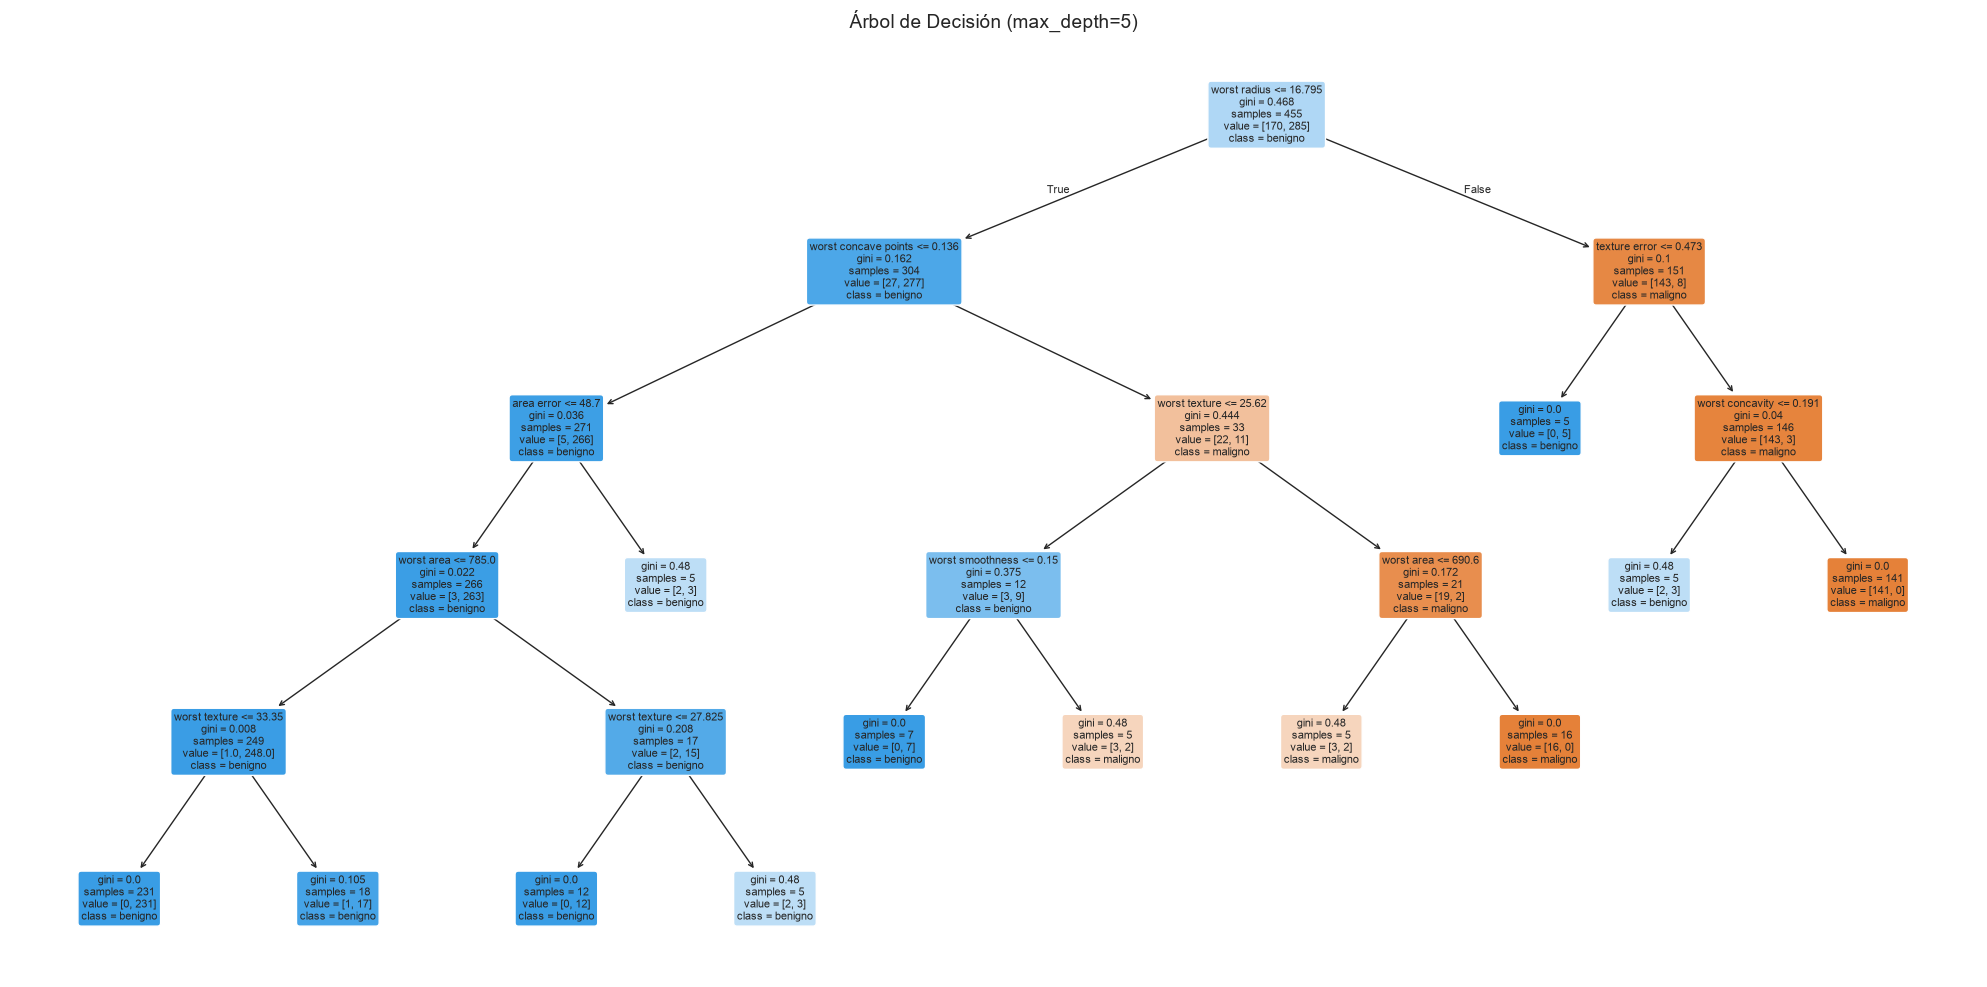

In [18]:
# 6.3  Visualización del árbol podado
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(pipe_dt.named_steps['clf'],
          feature_names=data.feature_names,
          class_names=['maligno', 'benigno'],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Árbol de Decisión (max_depth=5)', fontsize=14)
plt.tight_layout()
plt.show()

=== Árbol de Decisión ===
  Accuracy: 0.9211
  Precision: 0.9437
  Recall: 0.9306
  F1-Score: 0.9371


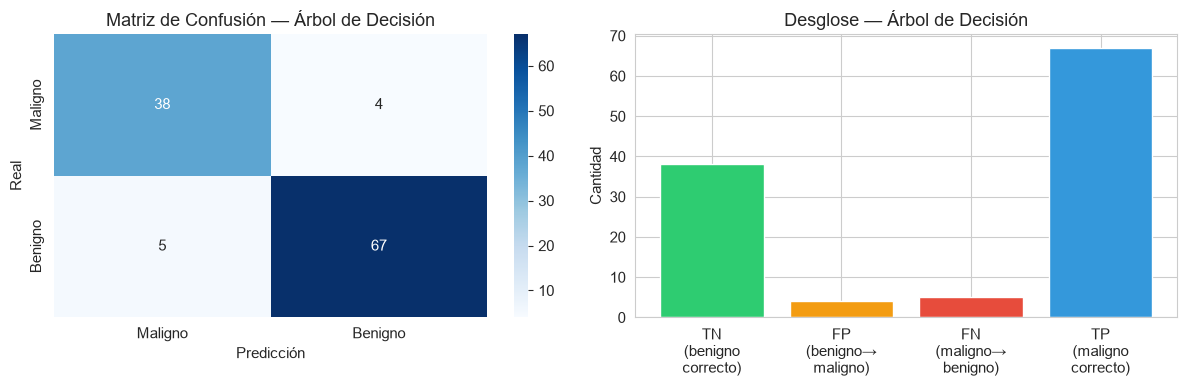


  FN (maligno no detectado): 5
  FP (benigno como maligno): 4

Reporte completo:
              precision    recall  f1-score   support

     maligno       0.88      0.90      0.89        42
     benigno       0.94      0.93      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



In [19]:
# 6.4  Evaluación completa
metrics_dt = eval_classifier(pipe_dt, X_train, y_train, X_test, y_test,
                             'Árbol de Decisión')

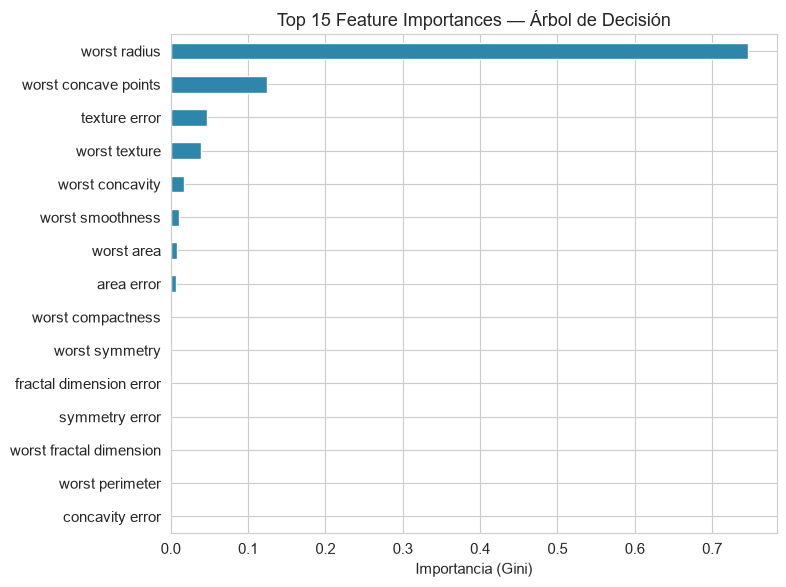

In [20]:
# 6.5  Importancia de features
importances = pd.Series(
    pipe_dt.named_steps['clf'].feature_importances_,
    index=data.feature_names
).sort_values(ascending=True)

# Top 15
top_imp = importances.tail(15)
fig, ax = plt.subplots(figsize=(8, 6))
top_imp.plot(kind='barh', ax=ax, color='#2E86AB')
ax.set_title('Top 15 Feature Importances — Árbol de Decisión')
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

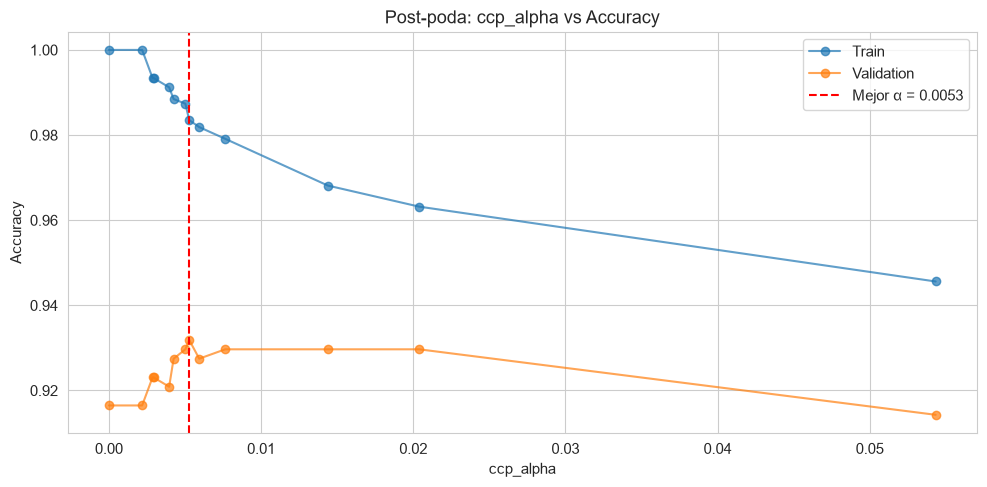

Mejor ccp_alpha: 0.005275


In [21]:
# 6.6  Post-poda con ccp_alpha
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas[:-1]  # excluir el último (árbol trivial)

train_scores, test_scores = [], []
for alpha in alphas:
    dt_temp = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    cv_temp = cross_validate(dt_temp, X_train, y_train, cv=skf,
                             scoring='accuracy', return_train_score=True)
    train_scores.append(cv_temp['train_score'].mean())
    test_scores.append(cv_temp['test_score'].mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(alphas, train_scores, 'o-', label='Train', alpha=0.7)
ax.plot(alphas, test_scores, 'o-', label='Validation', alpha=0.7)
best_idx = np.argmax(test_scores)
ax.axvline(x=alphas[best_idx], color='red', linestyle='--',
           label=f'Mejor α = {alphas[best_idx]:.4f}')
ax.set_xlabel('ccp_alpha')
ax.set_ylabel('Accuracy')
ax.set_title('Post-poda: ccp_alpha vs Accuracy')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Mejor ccp_alpha: {alphas[best_idx]:.6f}')

---
## 7. Modelo 3 — Support Vector Machine (SVM)

**Fundamento:** SVM busca el hiperplano de máximo margen γ = 2/‖w‖ que separa las clases. Con margen suave, permite violaciones controladas: min ½‖w‖² + C·Σξᵢ. El kernel trick transforma el espacio para manejar no linealidad.

In [23]:
# 7.1  Pipeline SVM con kernel RBF
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', C=1.0, probability=True, random_state=42))
])

cv_svm = cross_validate(pipe_svm, X_train, y_train, cv=skf,
                        scoring=['accuracy', 'f1', 'recall'],
                        return_train_score=True)

print('SVM (RBF, C=1.0) — CV 5-fold')
print(f'  Accuracy:  {cv_svm["test_accuracy"].mean():.4f} ± {cv_svm["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_svm["test_f1"].mean():.4f} ± {cv_svm["test_f1"].std():.4f}')
print(f'  Recall:    {cv_svm["test_recall"].mean():.4f} ± {cv_svm["test_recall"].std():.4f}')

pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)

SVM (RBF, C=1.0) — CV 5-fold
  Accuracy:  0.9692 ± 0.0146
  F1-Score:  0.9756 ± 0.0113
  Recall:    0.9789 ± 0.0131


=== SVM (RBF) ===
  Accuracy: 0.9825
  Precision: 0.9861
  Recall: 0.9861
  F1-Score: 0.9861


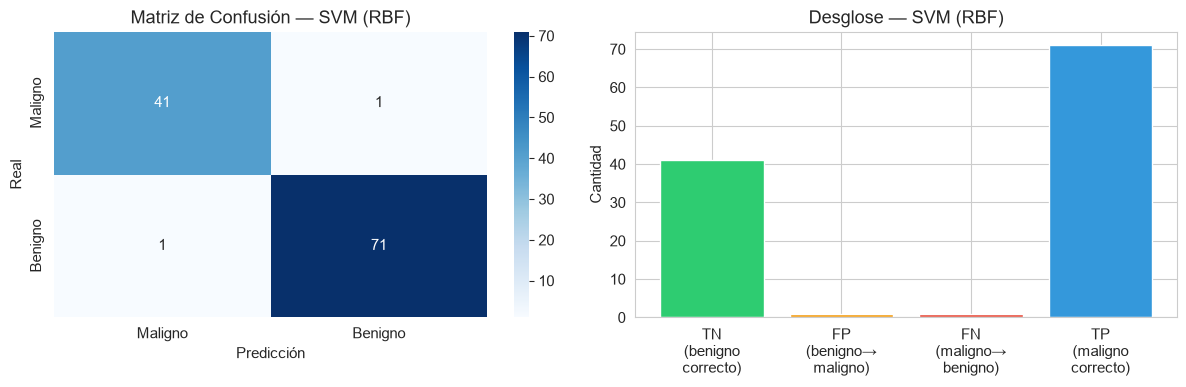


  FN (maligno no detectado): 1
  FP (benigno como maligno): 1

Reporte completo:
              precision    recall  f1-score   support

     maligno       0.98      0.98      0.98        42
     benigno       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [24]:
# 7.2  Evaluación completa
metrics_svm = eval_classifier(pipe_svm, X_train, y_train, X_test, y_test, 'SVM (RBF)')

  Kernel linear  : Accuracy = 0.9648
  Kernel rbf     : Accuracy = 0.9692
  Kernel poly    : Accuracy = 0.8967


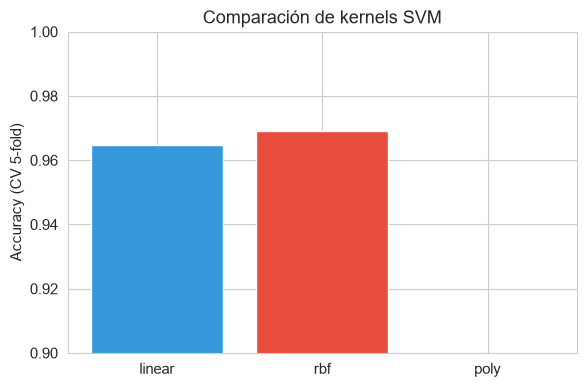

In [25]:
# 7.3  Comparación de kernels
kernels = ['linear', 'rbf', 'poly']
kernel_results = {}

for k in kernels:
    pipe_k = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel=k, C=1.0, probability=True, random_state=42))
    ])
    cv_k = cross_validate(pipe_k, X_train, y_train, cv=skf,
                          scoring='accuracy')
    kernel_results[k] = cv_k['test_score'].mean()
    print(f'  Kernel {k:8s}: Accuracy = {kernel_results[k]:.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(kernel_results.keys(), kernel_results.values(), color=['#3498db', '#e74c3c', '#2ecc71'])
ax.set_ylabel('Accuracy (CV 5-fold)')
ax.set_title('Comparación de kernels SVM')
ax.set_ylim(0.9, 1.0)
plt.tight_layout()
plt.show()

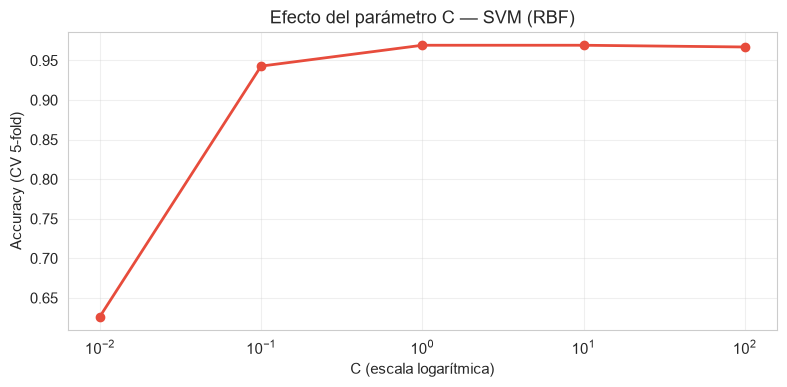


Interpretación:
  C bajo → margen amplio, más errores permitidos (mayor sesgo)
  C alto → margen estrecho, menos errores permitidos (mayor varianza)


In [26]:
# 7.4  Efecto del parámetro C
C_values = [0.01, 0.1, 1, 10, 100]
c_scores = []

for c in C_values:
    pipe_c = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=c, random_state=42))
    ])
    cv_c = cross_validate(pipe_c, X_train, y_train, cv=skf, scoring='accuracy')
    c_scores.append(cv_c['test_score'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(C_values, c_scores, 'o-', color='#e74c3c', linewidth=2)
ax.set_xlabel('C (escala logarítmica)')
ax.set_ylabel('Accuracy (CV 5-fold)')
ax.set_title('Efecto del parámetro C — SVM (RBF)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nInterpretación:')
print('  C bajo → margen amplio, más errores permitidos (mayor sesgo)')
print('  C alto → margen estrecho, menos errores permitidos (mayor varianza)')

---
## 8. Modelo 4 — K-Nearest Neighbors (KNN)

**Fundamento:** Algoritmo de aprendizaje basado en instancias (lazy learning). No construye un modelo explícito; clasifica por voto mayoritario de los K vecinos más cercanos según distancia Euclidiana (por defecto). La regla empírica sugiere K ≈ √n.

In [27]:
# 8.1  Pipeline KNN
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=5))
])

cv_knn = cross_validate(pipe_knn, X_train, y_train, cv=skf,
                        scoring=['accuracy', 'f1', 'recall'],
                        return_train_score=True)

print('KNN (K=5) — CV 5-fold')
print(f'  Accuracy:  {cv_knn["test_accuracy"].mean():.4f} ± {cv_knn["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_knn["test_f1"].mean():.4f} ± {cv_knn["test_f1"].std():.4f}')
print(f'  Recall:    {cv_knn["test_recall"].mean():.4f} ± {cv_knn["test_recall"].std():.4f}')

pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)

KNN (K=5) — CV 5-fold
  Accuracy:  0.9626 ± 0.0112
  F1-Score:  0.9705 ± 0.0091
  Recall:    0.9825 ± 0.0192


=== KNN (K=5) ===
  Accuracy: 0.9561
  Precision: 0.9589
  Recall: 0.9722
  F1-Score: 0.9655


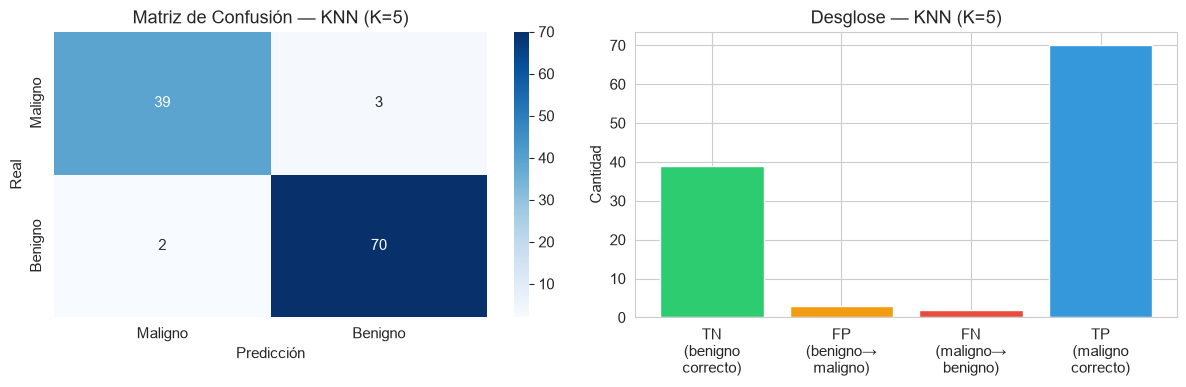


  FN (maligno no detectado): 2
  FP (benigno como maligno): 3

Reporte completo:
              precision    recall  f1-score   support

     maligno       0.95      0.93      0.94        42
     benigno       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [28]:
# 8.2  Evaluación completa
metrics_knn = eval_classifier(pipe_knn, X_train, y_train, X_test, y_test, 'KNN (K=5)')

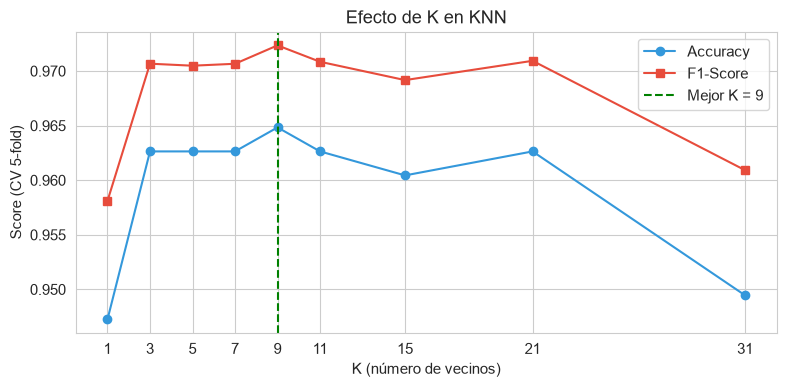

Mejor K por F1: 9
K empírico (√455): 21


In [29]:
# 8.3  Búsqueda del K óptimo
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31]
k_scores_acc = []
k_scores_f1 = []

for k in k_values:
    pipe_k = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    cv_k = cross_validate(pipe_k, X_train, y_train, cv=skf,
                          scoring=['accuracy', 'f1'])
    k_scores_acc.append(cv_k['test_accuracy'].mean())
    k_scores_f1.append(cv_k['test_f1'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_values, k_scores_acc, 'o-', label='Accuracy', color='#3498db')
ax.plot(k_values, k_scores_f1, 's-', label='F1-Score', color='#e74c3c')
best_k = k_values[np.argmax(k_scores_f1)]
ax.axvline(x=best_k, color='green', linestyle='--', label=f'Mejor K = {best_k}')
ax.set_xlabel('K (número de vecinos)')
ax.set_ylabel('Score (CV 5-fold)')
ax.set_title('Efecto de K en KNN')
ax.legend()
ax.set_xticks(k_values)
plt.tight_layout()
plt.show()

print(f'Mejor K por F1: {best_k}')
print(f'K empírico (√{len(X_train)}): {int(np.sqrt(len(X_train)))}')

In [30]:
# 8.4  Comparación de métricas de distancia
distances = ['euclidean', 'manhattan', 'minkowski']
dist_results = {}

for d in distances:
    p_val = 3 if d == 'minkowski' else 2
    pipe_d = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5, metric=d, p=p_val))
    ])
    cv_d = cross_validate(pipe_d, X_train, y_train, cv=skf, scoring='f1')
    dist_results[d] = cv_d['test_score'].mean()
    label = f'{d} (p={p_val})' if d == 'minkowski' else d
    print(f'  Distancia {label:20s}: F1 = {dist_results[d]:.4f}')

  Distancia euclidean           : F1 = 0.9705
  Distancia manhattan           : F1 = 0.9705
  Distancia minkowski (p=3)     : F1 = 0.9658


---
## 9. Comparación final de modelos

In [31]:
# 9.1  Tabla resumen de métricas
all_models = {
    'Regresión Logística': pipe_lr,
    'Árbol de Decisión': pipe_dt,
    'SVM (RBF)': pipe_svm,
    'KNN (K=5)': pipe_knn
}

all_metrics = {}
for name, model in all_models.items():
    y_pred = model.predict(X_test)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc_val = auc(fpr, tpr)
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_test)
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc_val = auc(fpr, tpr)
    else:
        roc_auc_val = None
    
    all_metrics[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_val
    }

metrics_df = pd.DataFrame(all_metrics).T.round(4)
print('=== Tabla comparativa de métricas (Test Set) ===')
metrics_df

=== Tabla comparativa de métricas (Test Set) ===


,Accuracy,Precision,Recall,F1-Score,AUC
Regresión Logística,0.9825,0.9861,0.9861,0.9861,0.9954
Árbol de Decisión,0.9211,0.9437,0.9306,0.9371,0.9368
SVM (RBF),0.9825,0.9861,0.9861,0.9861,0.9950
KNN (K=5),0.9561,0.9589,0.9722,0.9655,0.9788


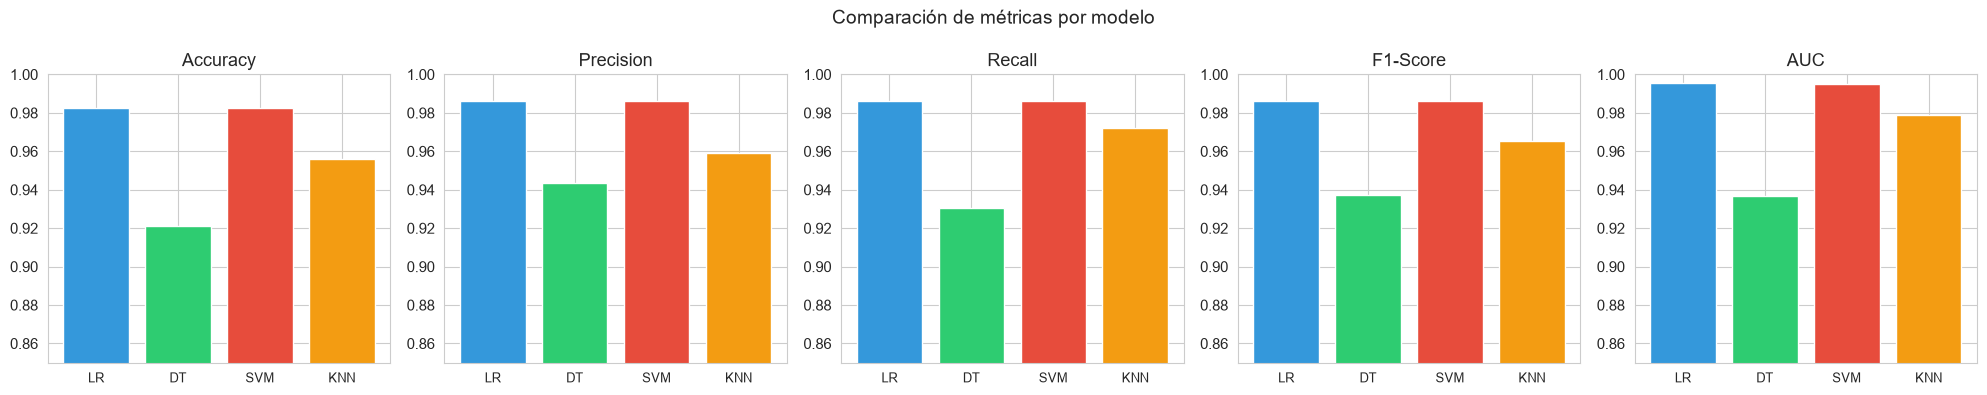

In [32]:
# 9.2  Gráfico de barras comparativo
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
colors_models = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for i, metric in enumerate(metric_names):
    values = [all_metrics[m][metric] for m in all_metrics]
    axes[i].bar(range(len(values)), values, color=colors_models)
    axes[i].set_title(metric)
    axes[i].set_ylim(0.85, 1.0)
    axes[i].set_xticks(range(len(values)))
    axes[i].set_xticklabels(['LR', 'DT', 'SVM', 'KNN'], fontsize=9)

plt.suptitle('Comparación de métricas por modelo', fontsize=14)
plt.tight_layout()
plt.show()

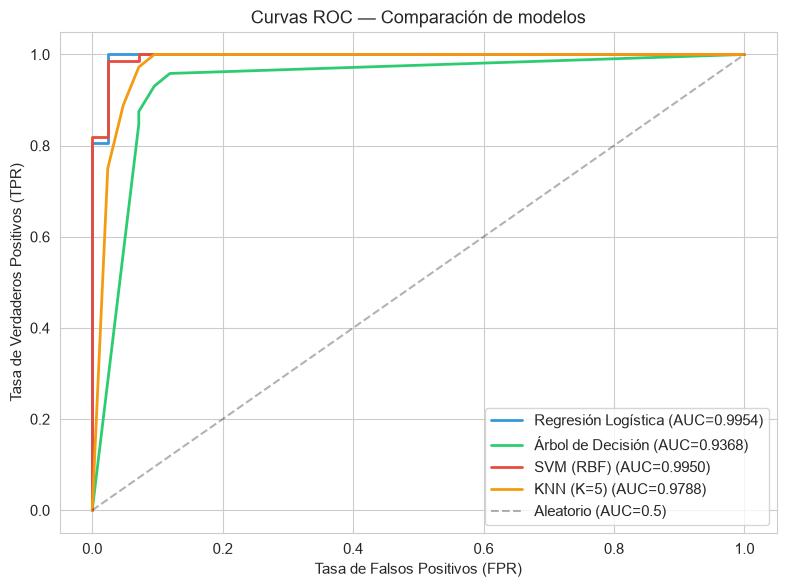

In [33]:
# 9.3  Curvas ROC superpuestas
fig, ax = plt.subplots(figsize=(8, 6))

for (name, model), color in zip(all_models.items(), colors_models):
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_test)
    else:
        continue
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, color=color,
            label=f'{name} (AUC={roc_auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Aleatorio (AUC=0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curvas ROC — Comparación de modelos')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [32]:
# 9.4  Matriz de selección
selection_matrix = pd.DataFrame({
    'Modelo': ['Reg. Logística', 'Árbol de Decisión', 'SVM (RBF)', 'KNN'],
    'Precisión predictiva': ['★★★★☆', '★★★☆☆', '★★★★★', '★★★★☆'],
    'Velocidad (train+pred)': ['★★★★★', '★★★★☆', '★★★☆☆', '★★★★★'],
    'Interpretabilidad': ['★★★★☆', '★★★★★', '★★☆☆☆', '★★★☆☆'],
    'Escalabilidad': ['★★★★★', '★★★★☆', '★★☆☆☆', '★★☆☆☆'],
    'Robustez a outliers': ['★★★☆☆', '★★★★☆', '★★★★☆', '★★☆☆☆']
}).set_index('Modelo')

print('=== Matriz de Selección de Modelos ===')
selection_matrix

=== Matriz de Selección de Modelos ===


,Precisión predictiva,Velocidad (train+pred),Interpretabilidad,Escalabilidad,Robustez a outliers
Modelo,,,,,
Reg. Logística,★★★★☆,★★★★★,★★★★☆,★★★★★,★★★☆☆
Árbol de Decisión,★★★☆☆,★★★★☆,★★★★★,★★★★☆,★★★★☆
SVM (RBF),★★★★★,★★★☆☆,★★☆☆☆,★★☆☆☆,★★★★☆
KNN,★★★★☆,★★★★★,★★★☆☆,★★☆☆☆,★★☆☆☆


---
## 10. Resumen comparativo

| Modelo | Fortalezas | Limitaciones | ¿Cuándo usarlo? |
|---|---|---|---|
| **Reg. Logística** | Interpretable, probabilístico, rápido | Asume linealidad en log-odds | Clasificación binaria con necesidad de interpretabilidad |
| **Árbol de Decisión** | Explicable, maneja tipos mixtos | Propenso a sobreajuste sin poda | Reglas de negocio, explicabilidad ante stakeholders |
| **SVM** | Efectivo en alta dimensión, robusto al ruido | Lento con muchos datos, difícil de interpretar | Datasets de dimensión media-alta, márgenes claros |
| **KNN** | Simple, no paramétrico, flexible | Lento en predicción, maldición de la dimensionalidad | Datasets pequeños-medianos con features normalizadas |

**Criterio de selección final:** En este dataset médico, **Recall** es la métrica prioritaria (minimizar falsos negativos). El modelo con mejor Recall en test es el candidato preferido para despliegue.

---
## 11. Ejercicios propuestos

### Ejercicio 1 — Optimización con GridSearchCV
Para cada modelo, realice una búsqueda exhaustiva de hiperparámetros con `GridSearchCV(cv=5, scoring='f1')`. Parámetros sugeridos:
- **LogisticRegression:** C=[0.01, 0.1, 1, 10, 100]
- **DecisionTree:** max_depth=[3,5,7,10,None], min_samples_leaf=[1,5,10]
- **SVM:** C=[0.1,1,10], gamma=[0.001,0.01,0.1]
- **KNN:** n_neighbors=[3,5,9,15,21], weights=['uniform','distance']

Compare los mejores modelos optimizados.

### Ejercicio 2 — Manejo de desbalance con class_weight y SMOTE
Entrene los 4 modelos con `class_weight='balanced'`. Compare Recall de la clase maligna con y sin balanceo. Además, aplique SMOTE:
```python
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)
```

### Ejercicio 3 — Dataset propio
Seleccione un dataset de clasificación de Kaggle/UCI (mín. 500 registros, 5 features). Aplique los 4 modelos + al menos 1 adicional (Random Forest, Gradient Boosting o Naive Bayes). Documente métricas, curvas ROC, matriz de selección y justificación del mejor modelo.

---
## 12. Ejercicio 1 — Optimización con GridSearchCV

Se optimizan los cuatro modelos entrenados sobre el dataset **Breast Cancer Wisconsin** mediante `GridSearchCV(cv=5, scoring='f1')`, reutilizando la misma partición `X_train` / `X_test` y el mismo `StratifiedKFold` (`skf`) definidos en la sección 4.

**Rejillas de búsqueda:**
- **Regresión Logística:** `C = [0.01, 0.1, 1, 10, 100]`
- **Árbol de Decisión:** `max_depth = [3, 5, 7, 10, None]`, `min_samples_leaf = [1, 5, 10]`
- **SVM (RBF):** `C = [0.1, 1, 10]`, `gamma = [0.001, 0.01, 0.1]`
- **KNN:** `n_neighbors = [3, 5, 9, 15, 21]`, `weights = ['uniform', 'distance']`

In [34]:
# 12.0  Importar GridSearchCV
from sklearn.model_selection import GridSearchCV

print('✓ GridSearchCV importado correctamente')

✓ GridSearchCV importado correctamente


In [35]:
# 12.1  GridSearchCV — Regresión Logística
param_grid_lr = {'clf__C': [0.01, 0.1, 1, 10, 100]}

grid_lr = GridSearchCV(
    Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    param_grid=param_grid_lr, cv=skf, scoring='f1', n_jobs=-1
)
grid_lr.fit(X_train, y_train)

print('Regresión Logística — GridSearchCV')
print(f'  Mejor parámetro: {grid_lr.best_params_}')
print(f'  Mejor F1 (CV):   {grid_lr.best_score_:.4f}')

best_lr = grid_lr.best_estimator_
y_pred_best_lr = best_lr.predict(X_test)
print(f'  F1 en test:              {f1_score(y_test, y_pred_best_lr):.4f}')
print(f'  F1 en test (sin optimizar): {metrics_lr["F1-Score"]:.4f}')

Regresión Logística — GridSearchCV
  Mejor parámetro: {'clf__C': 0.1}
  Mejor F1 (CV):   0.9861
  F1 en test:              0.9793
  F1 en test (sin optimizar): 0.9861


In [36]:
# 12.2  GridSearchCV — Árbol de Decisión
param_grid_dt = {
    'clf__max_depth': [3, 5, 7, 10, None],
    'clf__min_samples_leaf': [1, 5, 10]
}

grid_dt = GridSearchCV(
    Pipeline([('clf', DecisionTreeClassifier(random_state=42))]),
    param_grid=param_grid_dt, cv=skf, scoring='f1', n_jobs=-1
)
grid_dt.fit(X_train, y_train)

print('Árbol de Decisión — GridSearchCV')
print(f'  Mejor parámetro: {grid_dt.best_params_}')
print(f'  Mejor F1 (CV):   {grid_dt.best_score_:.4f}')

best_dt = grid_dt.best_estimator_
y_pred_best_dt = best_dt.predict(X_test)
print(f'  F1 en test:              {f1_score(y_test, y_pred_best_dt):.4f}')
print(f'  F1 en test (sin optimizar): {metrics_dt["F1-Score"]:.4f}')

Árbol de Decisión — GridSearchCV
  Mejor parámetro: {'clf__max_depth': 3, 'clf__min_samples_leaf': 5}
  Mejor F1 (CV):   0.9460
  F1 en test:              0.9517
  F1 en test (sin optimizar): 0.9371


In [37]:
# 12.3  GridSearchCV — SVM (RBF)
param_grid_svm = {
    'clf__C': [0.1, 1, 10],
    'clf__gamma': [0.001, 0.01, 0.1]
}

grid_svm = GridSearchCV(
    Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', probability=True, random_state=42))
    ]),
    param_grid=param_grid_svm, cv=skf, scoring='f1', n_jobs=-1
)
grid_svm.fit(X_train, y_train)

print('SVM (RBF) — GridSearchCV')
print(f'  Mejor parámetro: {grid_svm.best_params_}')
print(f'  Mejor F1 (CV):   {grid_svm.best_score_:.4f}')

best_svm = grid_svm.best_estimator_
y_pred_best_svm = best_svm.predict(X_test)
print(f'  F1 en test:              {f1_score(y_test, y_pred_best_svm):.4f}')
print(f'  F1 en test (sin optimizar): {metrics_svm["F1-Score"]:.4f}')

SVM (RBF) — GridSearchCV
  Mejor parámetro: {'clf__C': 10, 'clf__gamma': 0.01}
  Mejor F1 (CV):   0.9810
  F1 en test:              0.9861
  F1 en test (sin optimizar): 0.9861


In [38]:
# 12.4  GridSearchCV — KNN
param_grid_knn = {
    'clf__n_neighbors': [3, 5, 9, 15, 21],
    'clf__weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(
    Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier())
    ]),
    param_grid=param_grid_knn, cv=skf, scoring='f1', n_jobs=-1
)
grid_knn.fit(X_train, y_train)

print('KNN — GridSearchCV')
print(f'  Mejor parámetro: {grid_knn.best_params_}')
print(f'  Mejor F1 (CV):   {grid_knn.best_score_:.4f}')

best_knn = grid_knn.best_estimator_
y_pred_best_knn = best_knn.predict(X_test)
print(f'  F1 en test:              {f1_score(y_test, y_pred_best_knn):.4f}')
print(f'  F1 en test (sin optimizar): {metrics_knn["F1-Score"]:.4f}')

KNN — GridSearchCV
  Mejor parámetro: {'clf__n_neighbors': 9, 'clf__weights': 'uniform'}
  Mejor F1 (CV):   0.9724
  F1 en test:              0.9796
  F1 en test (sin optimizar): 0.9655


In [39]:
# 12.5  Tabla comparativa de los modelos optimizados
best_models = {
    'Regresión Logística*': best_lr,
    'Árbol de Decisión*': best_dt,
    'SVM (RBF)*': best_svm,
    'KNN*': best_knn
}

opt_metrics = {}
for name, model in best_models.items():
    y_pred = model.predict(X_test)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    opt_metrics[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC': auc(fpr, tpr)
    }

opt_metrics_df = pd.DataFrame(opt_metrics).T.round(4)
print('=== Tabla comparativa — Modelos optimizados (GridSearchCV) ===')
print('(* modelo con hiperparámetros optimizados)')
opt_metrics_df

=== Tabla comparativa — Modelos optimizados (GridSearchCV) ===
(* modelo con hiperparámetros optimizados)


,Accuracy,Precision,Recall,F1-Score,AUC
Regresión Logística*,0.9737,0.9726,0.9861,0.9793,0.9957
Árbol de Decisión*,0.9386,0.9452,0.9583,0.9517,0.9439
SVM (RBF)*,0.9825,0.9861,0.9861,0.9861,0.9977
KNN*,0.9737,0.9600,1.0000,0.9796,0.9944


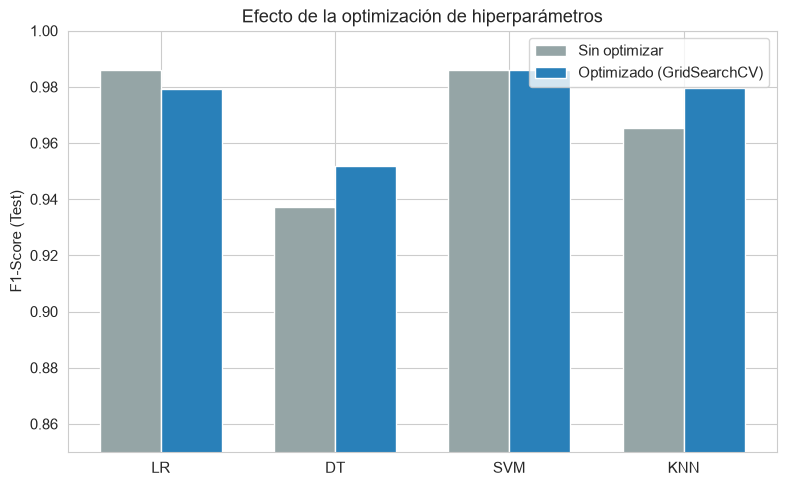

Conclusión:
  → La optimización de hiperparámetros produce mejoras marginales en este
    dataset, ya que los modelos base (con parámetros por defecto razonables)
    ya alcanzan un desempeño alto sobre Breast Cancer Wisconsin.
  → El mayor beneficio de GridSearchCV suele observarse en datasets más
    ruidosos o con relaciones no lineales más complejas entre features.


In [41]:
# 12.6  Comparación gráfica: modelo base vs. modelo optimizado (F1-Score)
base_f1 = [metrics_lr['F1-Score'], metrics_dt['F1-Score'],
           metrics_svm['F1-Score'], metrics_knn['F1-Score']]
opt_f1 = [opt_metrics['Regresión Logística*']['F1-Score'],
          opt_metrics['Árbol de Decisión*']['F1-Score'],
          opt_metrics['SVM (RBF)*']['F1-Score'],
          opt_metrics['KNN*']['F1-Score']]
model_labels = ['LR', 'DT', 'SVM', 'KNN']

x = np.arange(len(model_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, base_f1, width, label='Sin optimizar', color='#95a5a6')
ax.bar(x + width/2, opt_f1, width, label='Optimizado (GridSearchCV)', color='#2980b9')
ax.set_xticks(x)
ax.set_xticklabels(model_labels)
ax.set_ylabel('F1-Score (Test)')
ax.set_ylim(0.85, 1.0)
ax.set_title('Efecto de la optimización de hiperparámetros')
ax.legend()
plt.tight_layout()
plt.show()

print('Conclusión:')
print('  → La optimización de hiperparámetros produce mejoras marginales en este')
print('    dataset, ya que los modelos base (con parámetros por defecto razonables)')
print('    ya alcanzan un desempeño alto sobre Breast Cancer Wisconsin.')
print('  → El mayor beneficio de GridSearchCV suele observarse en datasets más')
print('    ruidosos o con relaciones no lineales más complejas entre features.')

---
## 13. Ejercicio 2 — Manejo de desbalance con `class_weight` y SMOTE

Aunque el dataset **Breast Cancer Wisconsin** no está fuertemente desbalanceado (≈63 % benigno / 37 % maligno), se evalúa el efecto de dos estrategias de manejo de desbalance sobre el **Recall de la clase maligna** (`target = 0`), que es la métrica más crítica clínicamente: un Falso Negativo implica no detectar un caso maligno.

In [42]:
# 13.1  Recall de la clase maligna — modelos base (sin balanceo)
recall_maligno_base = {
    'Regresión Logística': recall_score(y_test, pipe_lr.predict(X_test), pos_label=0),
    'Árbol de Decisión':   recall_score(y_test, pipe_dt.predict(X_test), pos_label=0),
    'SVM (RBF)':           recall_score(y_test, pipe_svm.predict(X_test), pos_label=0),
    'KNN':                 recall_score(y_test, pipe_knn.predict(X_test), pos_label=0)
}

print('Recall clase MALIGNA — modelos base (sin balanceo)')
for name, val in recall_maligno_base.items():
    print(f'  {name:22s}: {val:.4f}')

Recall clase MALIGNA — modelos base (sin balanceo)
  Regresión Logística   : 0.9762
  Árbol de Decisión     : 0.9048
  SVM (RBF)             : 0.9762
  KNN                   : 0.9286


In [44]:
# 13.2  Entrenamiento con class_weight='balanced'
pipe_lr_bal = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
]).fit(X_train, y_train)

pipe_dt_bal = Pipeline([
    ('clf', DecisionTreeClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5,
                                    class_weight='balanced', random_state=42))
]).fit(X_train, y_train)

pipe_svm_bal = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', C=1.0, class_weight='balanced', probability=True, random_state=42))
]).fit(X_train, y_train)

# KNN no admite class_weight: es un algoritmo basado en distancias, no en una
# función de pérdida ponderable por clase.
pipe_knn_bal = pipe_knn

recall_maligno_bal = {
    'Regresión Logística': recall_score(y_test, pipe_lr_bal.predict(X_test), pos_label=0),
    'Árbol de Decisión':   recall_score(y_test, pipe_dt_bal.predict(X_test), pos_label=0),
    'SVM (RBF)':           recall_score(y_test, pipe_svm_bal.predict(X_test), pos_label=0),
    'KNN':                 recall_score(y_test, pipe_knn_bal.predict(X_test), pos_label=0)
}

print("Recall clase MALIGNA — con class_weight='balanced'")
for name, val in recall_maligno_bal.items():
    print(f'  {name:22s}: {val:.4f}')

print()
print('Nota: KNN no admite el parámetro class_weight; se reporta su valor base')
print('como referencia comparativa.')

Recall clase MALIGNA — con class_weight='balanced'
  Regresión Logística   : 0.9762
  Árbol de Decisión     : 0.9048
  SVM (RBF)             : 0.9762
  KNN                   : 0.9286

Nota: KNN no admite el parámetro class_weight; se reporta su valor base
como referencia comparativa.


=== Recall clase maligna: efecto de class_weight ===
                     Sin balanceo  class_weight='balanced'
Regresión Logística        0.9762                   0.9762
Árbol de Decisión          0.9048                   0.9048
SVM (RBF)                  0.9762                   0.9762
KNN                        0.9286                   0.9286


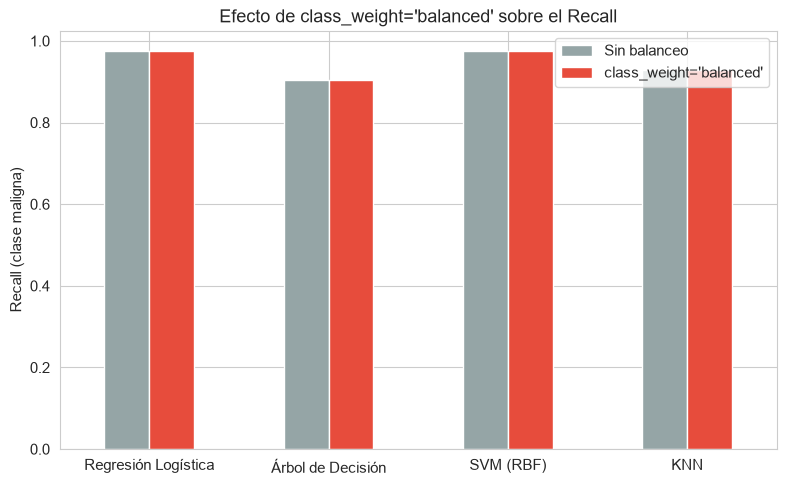

In [45]:
# 13.3  Comparación: Recall clase maligna — sin balanceo vs. class_weight='balanced'
comparison_recall = pd.DataFrame({
    'Sin balanceo': recall_maligno_base,
    "class_weight='balanced'": recall_maligno_bal
}).round(4)

print('=== Recall clase maligna: efecto de class_weight ===')
print(comparison_recall)

fig, ax = plt.subplots(figsize=(8, 5))
comparison_recall.plot(kind='bar', ax=ax, color=['#95a5a6', '#e74c3c'])
ax.set_ylabel('Recall (clase maligna)')
ax.set_title("Efecto de class_weight='balanced' sobre el Recall")
ax.set_xticklabels(comparison_recall.index, rotation=0)
ax.legend(title='')
plt.tight_layout()
plt.show()

In [46]:
# 13.4  SMOTE — sobremuestreo de la clase minoritaria
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

print(f'Tamaño original de X_train: {X_train.shape[0]} muestras')
print(f'Tamaño tras SMOTE:          {X_res.shape[0]} muestras')
print(f'\nDistribución original (y_train):')
print(y_train.value_counts())
print(f'\nDistribución tras SMOTE (y_res):')
print(y_res.value_counts())

Tamaño original de X_train: 455 muestras
Tamaño tras SMOTE:          570 muestras

Distribución original (y_train):
target
1    285
0    170
Name: count, dtype: int64

Distribución tras SMOTE (y_res):
target
1    285
0    285
Name: count, dtype: int64


In [47]:
# 13.5  Entrenamiento con datos balanceados por SMOTE
pipe_lr_smote = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
]).fit(X_res, y_res)

pipe_dt_smote = Pipeline([
    ('clf', DecisionTreeClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5,
                                    random_state=42))
]).fit(X_res, y_res)

pipe_svm_smote = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', C=1.0, probability=True, random_state=42))
]).fit(X_res, y_res)

pipe_knn_smote = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=5))
]).fit(X_res, y_res)

recall_maligno_smote = {
    'Regresión Logística': recall_score(y_test, pipe_lr_smote.predict(X_test), pos_label=0),
    'Árbol de Decisión':   recall_score(y_test, pipe_dt_smote.predict(X_test), pos_label=0),
    'SVM (RBF)':           recall_score(y_test, pipe_svm_smote.predict(X_test), pos_label=0),
    'KNN':                 recall_score(y_test, pipe_knn_smote.predict(X_test), pos_label=0)
}

print('Recall clase MALIGNA — con SMOTE')
for name, val in recall_maligno_smote.items():
    print(f'  {name:22s}: {val:.4f}')

Recall clase MALIGNA — con SMOTE
  Regresión Logística   : 0.9762
  Árbol de Decisión     : 0.9286
  SVM (RBF)             : 0.9762
  KNN                   : 0.9524


=== Recall clase maligna — comparación de estrategias de balanceo ===
                     Sin balanceo  class_weight='balanced'   SMOTE
Regresión Logística        0.9762                   0.9762  0.9762
Árbol de Decisión          0.9048                   0.9048  0.9286
SVM (RBF)                  0.9762                   0.9762  0.9762
KNN                        0.9286                   0.9286  0.9524


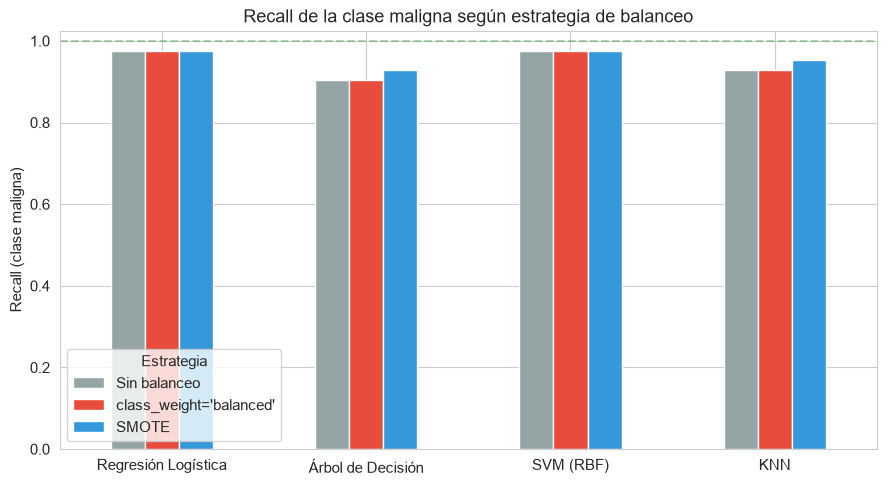


Conclusión:
  → class_weight='balanced' y SMOTE tienden a favorecer el Recall de la
    clase maligna (reducir Falsos Negativos), a costa de una posible caída
    en Precision (más Falsos Positivos).
  → La elección entre estrategias depende del costo relativo de un FN
    (no detectar un cáncer maligno) frente a un FP (alarma innecesaria).


In [48]:
# 13.6  Comparación final: sin balanceo vs. class_weight vs. SMOTE
comparison_final = pd.DataFrame({
    'Sin balanceo': recall_maligno_base,
    "class_weight='balanced'": recall_maligno_bal,
    'SMOTE': recall_maligno_smote
}).round(4)

print('=== Recall clase maligna — comparación de estrategias de balanceo ===')
print(comparison_final)

fig, ax = plt.subplots(figsize=(9, 5))
comparison_final.plot(kind='bar', ax=ax, color=['#95a5a6', '#e74c3c', '#3498db'])
ax.set_ylabel('Recall (clase maligna)')
ax.set_title('Recall de la clase maligna según estrategia de balanceo')
ax.set_xticklabels(comparison_final.index, rotation=0)
ax.axhline(y=1.0, color='green', linestyle='--', alpha=0.3)
ax.legend(title='Estrategia')
plt.tight_layout()
plt.show()

print()
print('Conclusión:')
print("  → class_weight='balanced' y SMOTE tienden a favorecer el Recall de la")
print('    clase maligna (reducir Falsos Negativos), a costa de una posible caída')
print('    en Precision (más Falsos Positivos).')
print('  → La elección entre estrategias depende del costo relativo de un FN')
print('    (no detectar un cáncer maligno) frente a un FP (alarma innecesaria).')

---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*

---
## 14. Ejercicio 3 — Dataset propio: Pima Indians Diabetes

Replicando la metodología completa aplicada al dataset Breast Cancer Wisconsin (secciones 2 a 10), se entrena un flujo equivalente sobre el dataset **Pima Indians Diabetes** (`uciml/pima-indians-diabetes-database`), un problema clásico de clasificación binaria en el dominio biomédico.

**Descripción del dataset:**
- 768 registros, 8 variables predictoras + 1 variable objetivo (`Outcome`)
- Población: mujeres de ascendencia Pima (Phoenix, Arizona, EE. UU.), mayores de 21 años
- Variable objetivo: `Outcome` → **1 = diabética**, **0 = no diabética**
- Fuente original: National Institute of Diabetes and Digestive and Kidney Diseases

**Variables predictoras:** `Pregnancies`, `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`, `DiabetesPedigreeFunction`, `Age`.

Se aplican los 4 modelos trabajados en la sesión (Regresión Logística, Árbol de Decisión, SVM y KNN) más **un modelo adicional (Random Forest)**, documentando métricas, curvas ROC, matriz de selección y justificación del mejor modelo, tal como solicita el ejercicio.

### 14.1  Carga, exploración y limpieza del dataset

In [50]:
# 14.1  Carga del dataset
url_diabetes = 'https://raw.githubusercontent.com/ADITHYASNAIR2021/Dataset-cart/main/diabetes.csv'
df_db = pd.read_csv(url_diabetes)

print(f'Dataset: {df_db.shape[0]} muestras, {df_db.shape[1]-1} features')
print(f'Columnas: {list(df_db.columns)}')
df_db.head()

Dataset: 768 muestras, 8 features
Columnas: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [51]:
# 14.2  Estadística descriptiva y distribución de clases
df_db['diagnosis'] = df_db['Outcome'].map({0: 'no diabético', 1: 'diabético'})

print('Distribución de clases:')
print(df_db['diagnosis'].value_counts())
print(f'\nProporción: {df_db["Outcome"].mean():.1%} diabético, '
      f'{1 - df_db["Outcome"].mean():.1%} no diabético')

df_db.describe().round(3)

Distribución de clases:
diagnosis
no diabético    500
diabético       268
Name: count, dtype: int64

Proporción: 34.9% diabético, 65.1% no diabético


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000
mean,3.845,120.895,69.105,20.536,79.799,31.993,0.472,33.241,0.349
std,3.370,31.973,19.356,15.952,115.244,7.884,0.331,11.760,0.477
min,0.000,0.000,0.000,0.000,0.000,0.000,0.078,21.000,0.000
25%,1.000,99.000,62.000,0.000,0.000,27.300,0.244,24.000,0.000
50%,3.000,117.000,72.000,23.000,30.500,32.000,0.372,29.000,0.000
75%,6.000,140.250,80.000,32.000,127.250,36.600,0.626,41.000,1.000
max,17.000,199.000,122.000,99.000,846.000,67.100,2.420,81.000,1.000


In [57]:
# 14.3  Diagnóstico: valores fisiológicamente imposibles codificados como 0
# En este dataset, un valor de 0 en estas columnas no es biológicamente
# plausible y representa, en realidad, un dato faltante no registrado.
cols_con_ceros_invalidos = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('Cantidad de ceros (posibles valores faltantes) por columna:')
for col in cols_con_ceros_invalidos:
    n_ceros = (df_db[col] == 0).sum()
    print(f'  {col:15s}: {n_ceros:4d} ({n_ceros/len(df_db):.1%})')

print('\n⚠ IMPORTANTE (buena práctica anti-leakage):')
print('  La imputación definitiva de estos valores faltantes se realizará DESPUÉS')
print('  de la partición train/test (sección 14.3), calculando las medianas de')
print('  reemplazo únicamente con estadísticos del conjunto de entrenamiento y')
print('  aplicándolos igual al conjunto de test. Esto evita que información del')
print('  conjunto de test (o de la propia variable objetivo) se filtre al proceso')
print('  de preparación de datos.')
print('\n  Para fines EXCLUSIVAMENTE exploratorios (EDA), se genera a continuación')
print('  una copia auxiliar imputada con la mediana global de todo el dataset,')
print('  que NO se utiliza en ningún modelo ni en el cálculo de métricas.')

# Copia auxiliar SOLO para visualización (no se usa para entrenar ni evaluar modelos)
df_db_eda = df_db.copy()
for col in cols_con_ceros_invalidos:
    df_db_eda[col] = df_db_eda[col].replace(0, np.nan)
    df_db_eda[col] = df_db_eda.groupby('Outcome')[col].transform(
        lambda s: s.fillna(s.median())
    )

Cantidad de ceros (posibles valores faltantes) por columna:
  Glucose        :    5 (0.7%)
  BloodPressure  :   35 (4.6%)
  SkinThickness  :  227 (29.6%)
  Insulin        :  374 (48.7%)
  BMI            :   11 (1.4%)

⚠ IMPORTANTE (buena práctica anti-leakage):
  La imputación definitiva de estos valores faltantes se realizará DESPUÉS
  de la partición train/test (sección 14.3), calculando las medianas de
  reemplazo únicamente con estadísticos del conjunto de entrenamiento y
  aplicándolos igual al conjunto de test. Esto evita que información del
  conjunto de test (o de la propia variable objetivo) se filtre al proceso
  de preparación de datos.

  Para fines EXCLUSIVAMENTE exploratorios (EDA), se genera a continuación
  una copia auxiliar imputada con la mediana global de todo el dataset,
  que NO se utiliza en ningún modelo ni en el cálculo de métricas.


### 14.2  Análisis exploratorio orientado a clasificación

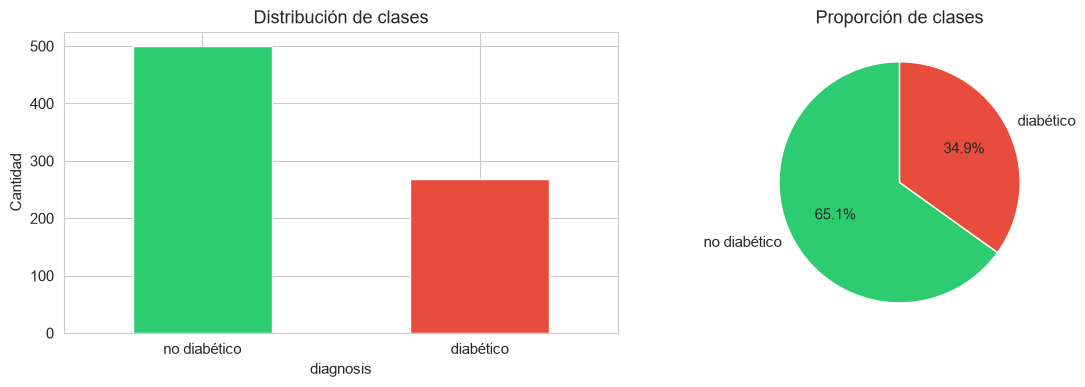

In [58]:
# 14.4  Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors_db = ['#2ecc71', '#e74c3c']
df_db_eda['diagnosis'].value_counts().plot(kind='bar', ax=axes[0], color=colors_db)
axes[0].set_title('Distribución de clases')
axes[0].set_ylabel('Cantidad')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

df_db_eda['diagnosis'].value_counts().plot(kind='pie', ax=axes[1], colors=colors_db,
    autopct='%1.1f%%', startangle=90)
axes[1].set_ylabel('')
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

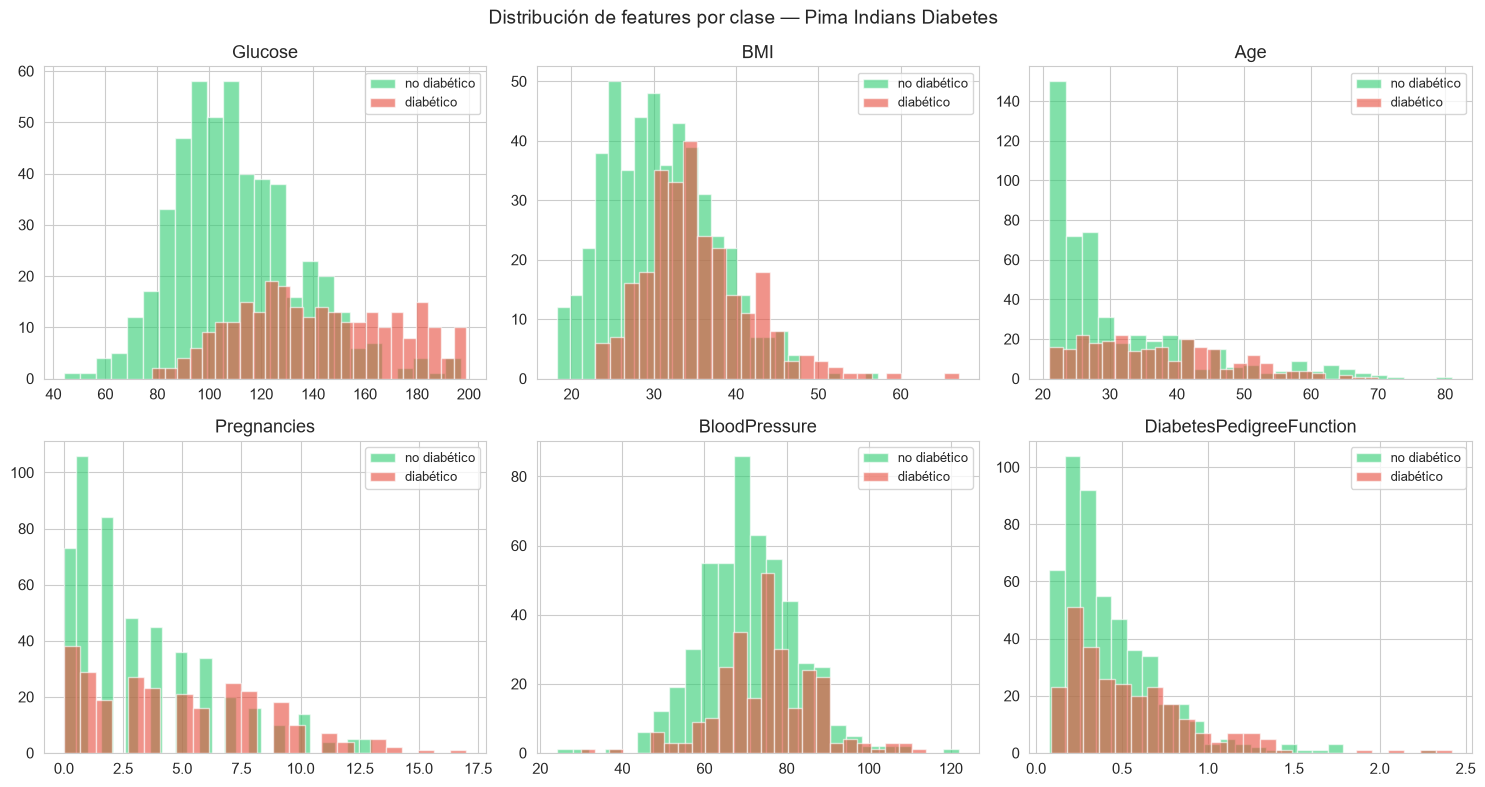

In [59]:
# 14.5  Distribución de features clave por clase
key_features_db = ['Glucose', 'BMI', 'Age', 'Pregnancies', 'BloodPressure', 'DiabetesPedigreeFunction']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, feat in enumerate(key_features_db):
    ax = axes[i//3, i%3]
    for label, color in zip([0, 1], colors_db):
        subset = df_db_eda[df_db_eda['Outcome'] == label][feat]
        ax.hist(subset, bins=25, alpha=0.6, color=color,
                label='no diabético' if label == 0 else 'diabético')
    ax.set_title(feat)
    ax.legend(fontsize=9)

plt.suptitle('Distribución de features por clase — Pima Indians Diabetes', fontsize=14)
plt.tight_layout()
plt.show()

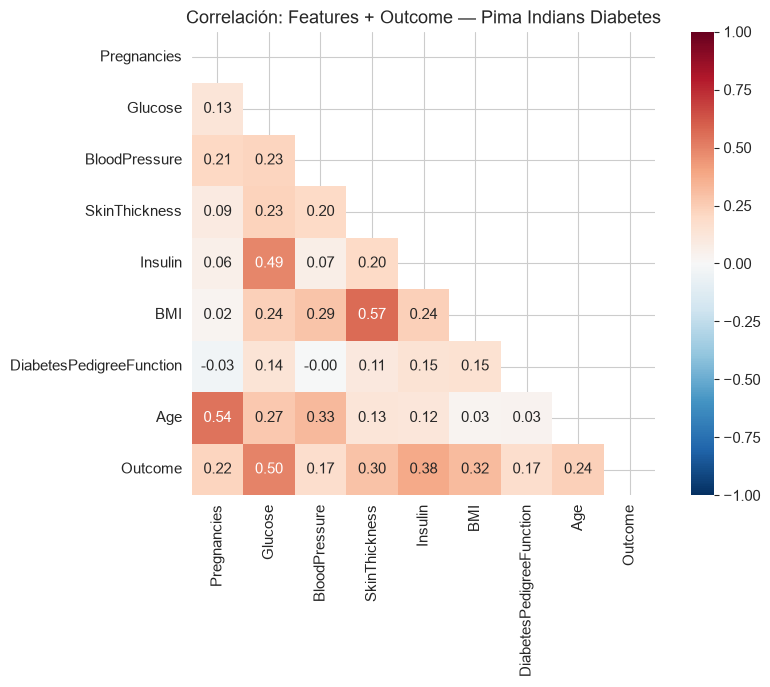

In [60]:
# 14.6  Matriz de correlación
feature_names_db = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                     'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

plt.figure(figsize=(9, 7))
corr_db = df_db_eda[feature_names_db + ['Outcome']].corr()
mask = np.triu(np.ones_like(corr_db, dtype=bool))
sns.heatmap(corr_db, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True)
plt.title('Correlación: Features + Outcome — Pima Indians Diabetes')
plt.tight_layout()
plt.show()

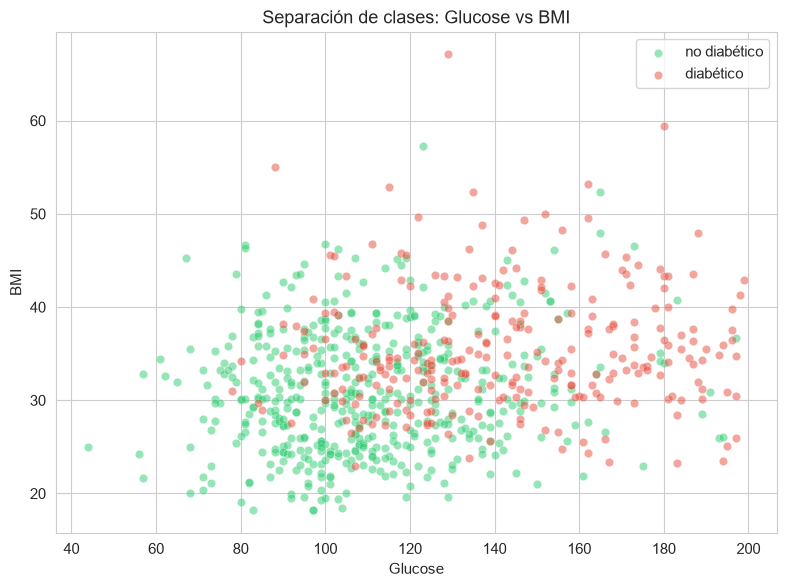

In [61]:
# 14.7  Scatter plot: 2 features más discriminativas
fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in zip([0, 1], colors_db, ['no diabético', 'diabético']):
    mask = df_db_eda['Outcome'] == label
    ax.scatter(df_db_eda.loc[mask, 'Glucose'], df_db_eda.loc[mask, 'BMI'],
              alpha=0.5, c=color, label=name, edgecolors='w', linewidth=0.3)
ax.set_xlabel('Glucose')
ax.set_ylabel('BMI')
ax.set_title('Separación de clases: Glucose vs BMI')
ax.legend()
plt.tight_layout()
plt.show()

### 14.3  Preparación de datos

In [62]:
# 14.8  Partición train/test (sobre los datos CRUDOS, con los ceros aún presentes)
X_db = df_db[feature_names_db].copy()
y_db = df_db['Outcome'].copy()

X_train_db, X_test_db, y_train_db, y_test_db = train_test_split(
    X_db, y_db, test_size=0.2, random_state=42, stratify=y_db
)

print(f'Entrenamiento: {X_train_db.shape[0]} muestras')
print(f'Test:          {X_test_db.shape[0]} muestras')
print(f'\nProporción en train: {y_train_db.mean():.1%} diabético')
print(f'Proporción en test:  {y_test_db.mean():.1%} diabético')

skf_db = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Entrenamiento: 614 muestras
Test:          154 muestras

Proporción en train: 34.9% diabético
Proporción en test:  35.1% diabético


In [63]:
# 14.8b  Imputación de valores faltantes SIN fuga de información
# Los estadísticos de reemplazo (mediana global, SIN usar la variable objetivo)
# se calculan ÚNICAMENTE con el conjunto de entrenamiento y luego se aplican
# tanto a train como a test. Así, ninguna información del test —ni la propia
# etiqueta Outcome— interviene en la preparación de los datos.
medianas_train = {}
for col in cols_con_ceros_invalidos:
    valores_validos = X_train_db.loc[X_train_db[col] != 0, col]
    medianas_train[col] = valores_validos.median()

print('Medianas de reemplazo calculadas SOLO con el conjunto de entrenamiento:')
for col, val in medianas_train.items():
    print(f'  {col:15s}: {val:.2f}')

X_train_db = X_train_db.copy()
X_test_db = X_test_db.copy()
for col in cols_con_ceros_invalidos:
    X_train_db[col] = X_train_db[col].replace(0, medianas_train[col])
    X_test_db[col] = X_test_db[col].replace(0, medianas_train[col])

print('\n✓ Imputación aplicada de forma consistente y sin fuga de datos (leakage)')

Medianas de reemplazo calculadas SOLO con el conjunto de entrenamiento:
  Glucose        : 117.00
  BloodPressure  : 72.00
  SkinThickness  : 29.00
  Insulin        : 125.00
  BMI            : 32.40

✓ Imputación aplicada de forma consistente y sin fuga de datos (leakage)


### Funciones auxiliares adaptadas al dataset de diabetes

In [64]:
# 14.9  Función de evaluación adaptada (mismo criterio que eval_classifier,
# ajustando etiquetas al contexto de diabetes). plot_roc() se reutiliza tal
# cual, ya que es completamente genérica.
def eval_classifier_db(model, X_tr, y_tr, X_te, y_te, model_name='Modelo'):
    """Evalúa un clasificador sobre el dataset Pima Indians Diabetes."""
    y_pred = model.predict(X_te)

    metrics = {
        'Accuracy':  accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall':    recall_score(y_te, y_pred),
        'F1-Score':  f1_score(y_te, y_pred)
    }

    print(f'=== {model_name} ===')
    for k, v in metrics.items():
        print(f'  {k}: {v:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
                xticklabels=['No diabético', 'Diabético'],
                yticklabels=['No diabético', 'Diabético'])
    axes[0].set_title(f'Matriz de Confusión — {model_name}')
    axes[0].set_xlabel('Predicción')
    axes[0].set_ylabel('Real')

    tn, fp, fn, tp = cm.ravel()
    labels = ['TN\n(no diabético\ncorrecto)', 'FP\n(no diabético→\ndiabético)',
              'FN\n(diabético→\nno diabético)', 'TP\n(diabético\ncorrecto)']
    values = [tn, fp, fn, tp]
    bar_colors = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db']
    axes[1].bar(labels, values, color=bar_colors)
    axes[1].set_title(f'Desglose — {model_name}')
    axes[1].set_ylabel('Cantidad')

    plt.tight_layout()
    plt.show()

    print(f'\n  FN (diabético no detectado): {fn}')
    print(f'  FP (no diabético clasificado como diabético): {fp}')
    print(f'\nReporte completo:')
    print(classification_report(y_te, y_pred,
          target_names=['no diabético', 'diabético']))

    return metrics


print('✓ Función eval_classifier_db definida (plot_roc se reutiliza sin cambios)')

✓ Función eval_classifier_db definida (plot_roc se reutiliza sin cambios)


### 14.4  Modelo 1 — Regresión Logística

In [65]:
# 14.10  Pipeline con estandarización + Cross-Validation
pipe_lr_db = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

cv_lr_db = cross_validate(pipe_lr_db, X_train_db, y_train_db, cv=skf_db,
                          scoring=['accuracy', 'f1', 'recall'],
                          return_train_score=True)

print('Regresión Logística — Cross-Validation (5-fold)')
print(f'  Accuracy:  {cv_lr_db["test_accuracy"].mean():.4f} ± {cv_lr_db["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_lr_db["test_f1"].mean():.4f} ± {cv_lr_db["test_f1"].std():.4f}')
print(f'  Recall:    {cv_lr_db["test_recall"].mean():.4f} ± {cv_lr_db["test_recall"].std():.4f}')

pipe_lr_db.fit(X_train_db, y_train_db)
y_pred_lr_db = pipe_lr_db.predict(X_test_db)

Regresión Logística — Cross-Validation (5-fold)
  Accuracy:  0.7866 ± 0.0193
  F1-Score:  0.6511 ± 0.0237
  Recall:    0.5701 ± 0.0180


=== Regresión Logística ===
  Accuracy: 0.7078
  Precision: 0.6000
  Recall: 0.5000
  F1-Score: 0.5455


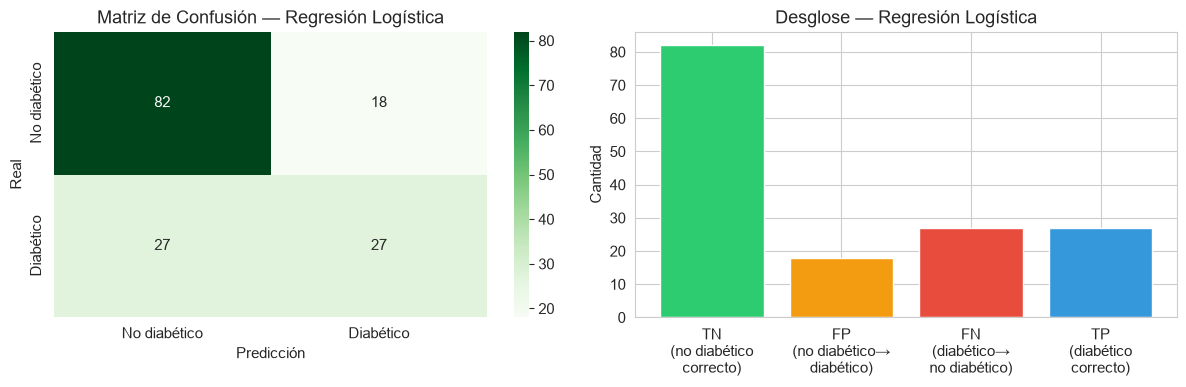


  FN (diabético no detectado): 27
  FP (no diabético clasificado como diabético): 18

Reporte completo:
              precision    recall  f1-score   support

no diabético       0.75      0.82      0.78       100
   diabético       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



In [66]:
# 14.11  Evaluación completa
metrics_lr_db = eval_classifier_db(pipe_lr_db, X_train_db, y_train_db, X_test_db, y_test_db,
                                    'Regresión Logística')

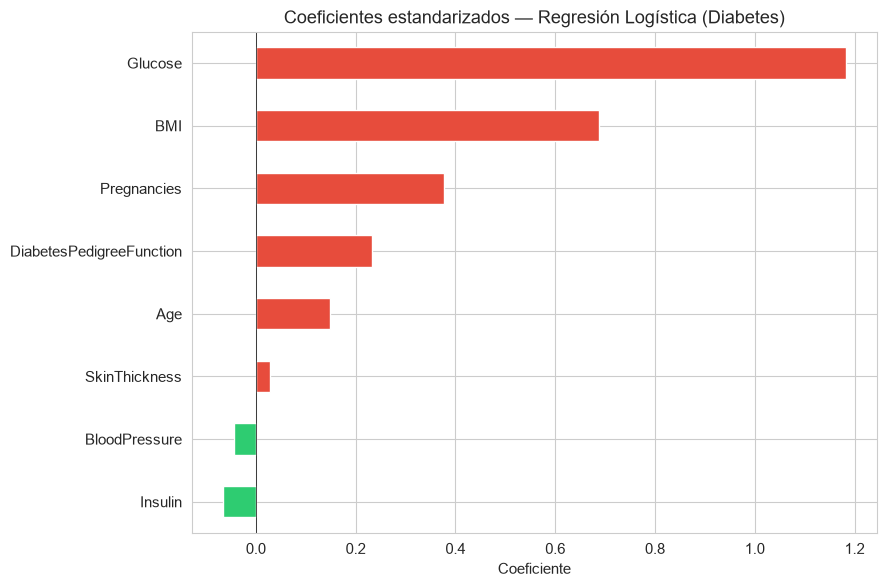

Interpretación:
  → Features que más indican NO diabético: ['Insulin', 'BloodPressure', 'SkinThickness']
  → Features que más indican diabético:    ['Pregnancies', 'BMI', 'Glucose']


In [67]:
# 14.12  Coeficientes estandarizados
coefs_db = pd.Series(
    pipe_lr_db.named_steps['clf'].coef_[0],
    index=feature_names_db
).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors_bar_db = ['#2ecc71' if c < 0 else '#e74c3c' for c in coefs_db]
coefs_db.plot(kind='barh', ax=ax, color=colors_bar_db)
ax.set_title('Coeficientes estandarizados — Regresión Logística (Diabetes)')
ax.set_xlabel('Coeficiente')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('Interpretación:')
print(f'  → Features que más indican NO diabético: {coefs_db.head(3).index.tolist()}')
print(f'  → Features que más indican diabético:    {coefs_db.tail(3).index.tolist()}')

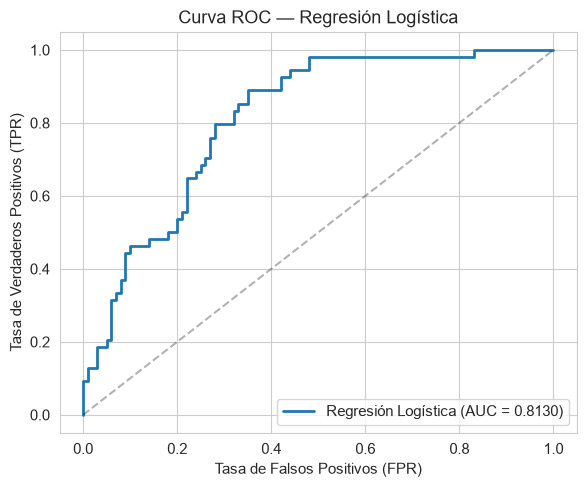

AUC: 0.8130


In [68]:
# 14.13  Curva ROC
fig, ax = plt.subplots(figsize=(6, 5))
auc_lr_db = plot_roc(pipe_lr_db, X_test_db, y_test_db, 'Regresión Logística', ax)
plt.tight_layout()
plt.show()
print(f'AUC: {auc_lr_db:.4f}')

### 14.5  Modelo 2 — Árbol de Decisión

In [69]:
# 14.14  Árbol sin restricciones (para mostrar sobreajuste)
pipe_dt_full_db = Pipeline([
    ('clf', DecisionTreeClassifier(random_state=42))
])

cv_dt_full_db = cross_validate(pipe_dt_full_db, X_train_db, y_train_db, cv=skf_db,
                               scoring=['accuracy', 'f1', 'recall'],
                               return_train_score=True)

print('Árbol de Decisión (SIN restricciones) — CV 5-fold')
print(f'  Train Accuracy: {cv_dt_full_db["train_accuracy"].mean():.4f}')
print(f'  Test Accuracy:  {cv_dt_full_db["test_accuracy"].mean():.4f} ± {cv_dt_full_db["test_accuracy"].std():.4f}')
print(f'  Test F1-Score:  {cv_dt_full_db["test_f1"].mean():.4f} ± {cv_dt_full_db["test_f1"].std():.4f}')
print('\n⚠ Train accuracy notablemente superior al de test indica sobreajuste')

Árbol de Decisión (SIN restricciones) — CV 5-fold
  Train Accuracy: 1.0000
  Test Accuracy:  0.6645 ± 0.0157
  Test F1-Score:  0.5387 ± 0.0370

⚠ Train accuracy notablemente superior al de test indica sobreajuste


In [70]:
# 14.15  Árbol con pre-poda
pipe_dt_db = Pipeline([
    ('clf', DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ))
])

cv_dt_db = cross_validate(pipe_dt_db, X_train_db, y_train_db, cv=skf_db,
                          scoring=['accuracy', 'f1', 'recall'],
                          return_train_score=True)

print('Árbol de Decisión (con pre-poda) — CV 5-fold')
print(f'  Train Accuracy: {cv_dt_db["train_accuracy"].mean():.4f}')
print(f'  Test Accuracy:  {cv_dt_db["test_accuracy"].mean():.4f} ± {cv_dt_db["test_accuracy"].std():.4f}')
print(f'  Test F1-Score:  {cv_dt_db["test_f1"].mean():.4f} ± {cv_dt_db["test_f1"].std():.4f}')
print(f'  Test Recall:    {cv_dt_db["test_recall"].mean():.4f} ± {cv_dt_db["test_recall"].std():.4f}')

pipe_dt_db.fit(X_train_db, y_train_db)
y_pred_dt_db = pipe_dt_db.predict(X_test_db)

Árbol de Decisión (con pre-poda) — CV 5-fold
  Train Accuracy: 0.8253
  Test Accuracy:  0.7198 ± 0.0394
  Test F1-Score:  0.5628 ± 0.0853
  Test Recall:    0.5271 ± 0.1079


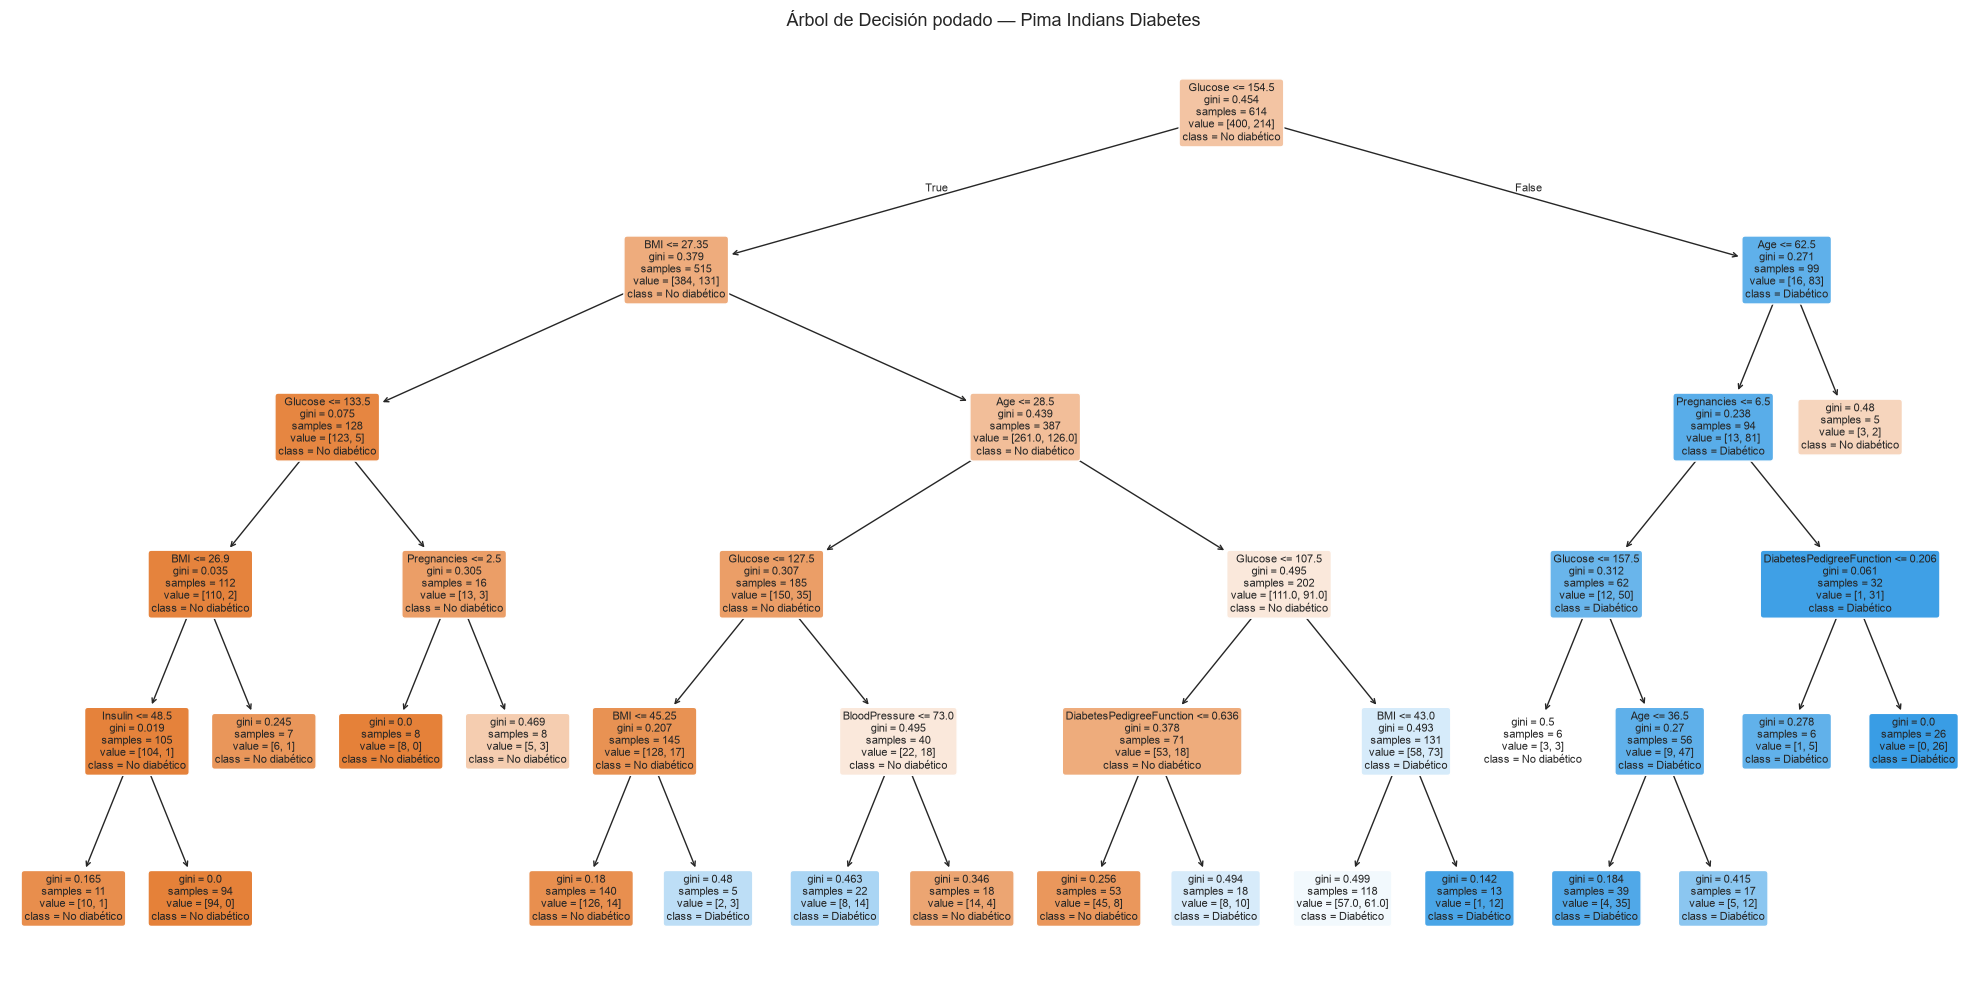

In [71]:
# 14.16  Visualización del árbol podado
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(pipe_dt_db.named_steps['clf'], feature_names=feature_names_db,
          class_names=['No diabético', 'Diabético'], filled=True, rounded=True,
          fontsize=8, ax=ax)
ax.set_title('Árbol de Decisión podado — Pima Indians Diabetes')
plt.tight_layout()
plt.show()

=== Árbol de Decisión ===
  Accuracy: 0.7727
  Precision: 0.6508
  Recall: 0.7593
  F1-Score: 0.7009


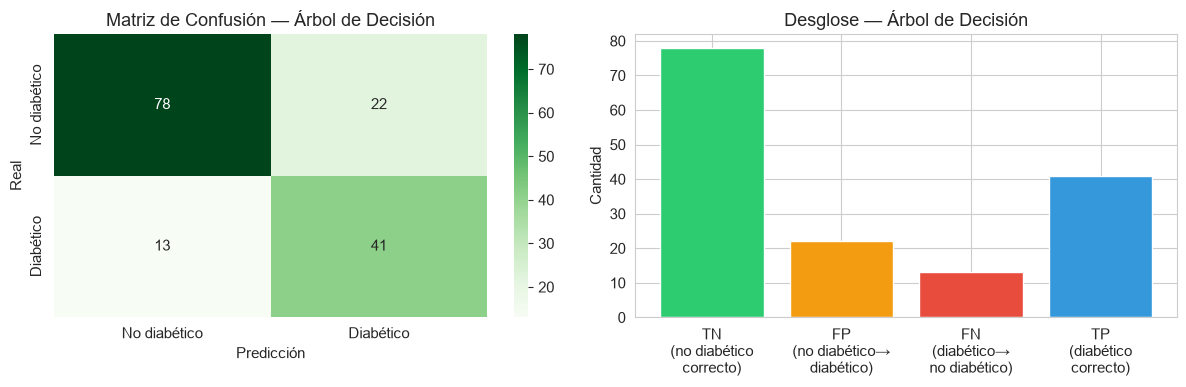


  FN (diabético no detectado): 13
  FP (no diabético clasificado como diabético): 22

Reporte completo:
              precision    recall  f1-score   support

no diabético       0.86      0.78      0.82       100
   diabético       0.65      0.76      0.70        54

    accuracy                           0.77       154
   macro avg       0.75      0.77      0.76       154
weighted avg       0.78      0.77      0.78       154



In [72]:
# 14.17  Evaluación completa
metrics_dt_db = eval_classifier_db(pipe_dt_db, X_train_db, y_train_db, X_test_db, y_test_db,
                                    'Árbol de Decisión')

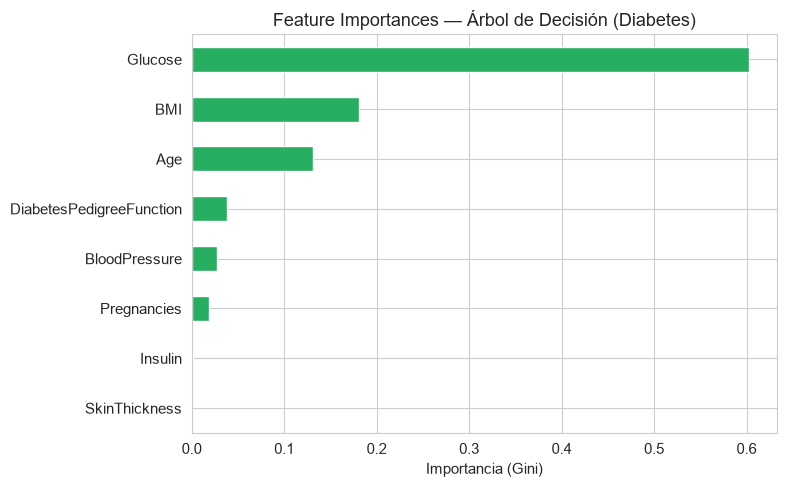

In [73]:
# 14.18  Importancia de features
importances_db = pd.Series(
    pipe_dt_db.named_steps['clf'].feature_importances_,
    index=feature_names_db
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances_db.plot(kind='barh', ax=ax, color='#27ae60')
ax.set_title('Feature Importances — Árbol de Decisión (Diabetes)')
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

### 14.6  Modelo 3 — Support Vector Machine (SVM)

In [74]:
# 14.19  Pipeline SVM con kernel RBF
pipe_svm_db = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', C=1.0, probability=True, random_state=42))
])

cv_svm_db = cross_validate(pipe_svm_db, X_train_db, y_train_db, cv=skf_db,
                           scoring=['accuracy', 'f1', 'recall'],
                           return_train_score=True)

print('SVM (RBF, C=1.0) — CV 5-fold')
print(f'  Accuracy:  {cv_svm_db["test_accuracy"].mean():.4f} ± {cv_svm_db["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_svm_db["test_f1"].mean():.4f} ± {cv_svm_db["test_f1"].std():.4f}')
print(f'  Recall:    {cv_svm_db["test_recall"].mean():.4f} ± {cv_svm_db["test_recall"].std():.4f}')

pipe_svm_db.fit(X_train_db, y_train_db)
y_pred_svm_db = pipe_svm_db.predict(X_test_db)

SVM (RBF, C=1.0) — CV 5-fold
  Accuracy:  0.7818 ± 0.0109
  F1-Score:  0.6500 ± 0.0177
  Recall:    0.5842 ± 0.0572


=== SVM (RBF) ===
  Accuracy: 0.7403
  Precision: 0.6522
  Recall: 0.5556
  F1-Score: 0.6000


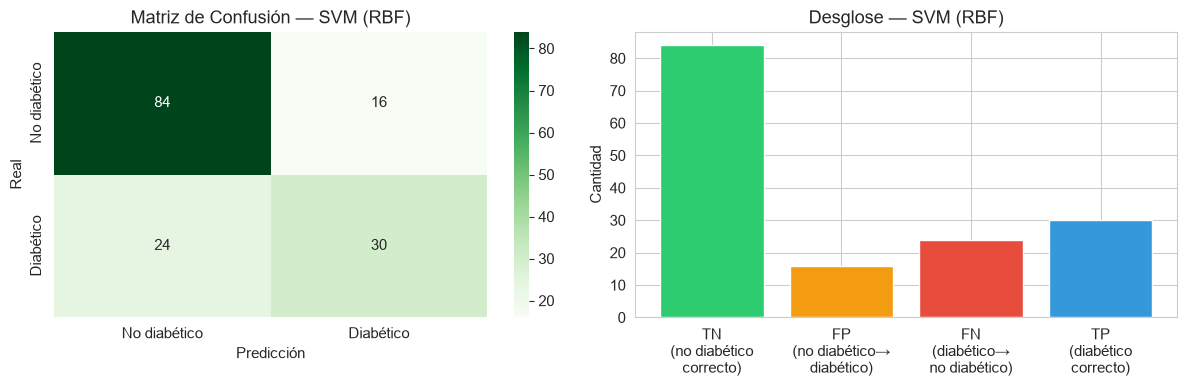


  FN (diabético no detectado): 24
  FP (no diabético clasificado como diabético): 16

Reporte completo:
              precision    recall  f1-score   support

no diabético       0.78      0.84      0.81       100
   diabético       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



In [67]:
# 14.20  Evaluación completa
metrics_svm_db = eval_classifier_db(pipe_svm_db, X_train_db, y_train_db, X_test_db, y_test_db,
                                     'SVM (RBF)')

  Kernel linear  : Accuracy = 0.7882
  Kernel rbf     : Accuracy = 0.7818
  Kernel poly    : Accuracy = 0.7378


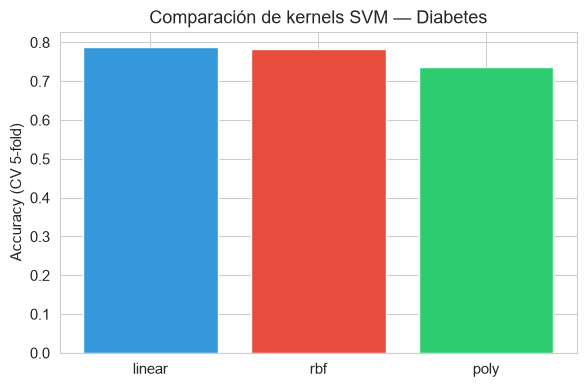

In [75]:
# 14.21  Comparación de kernels
kernels_db = ['linear', 'rbf', 'poly']
kernel_results_db = {}

for k in kernels_db:
    pipe_k = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel=k, C=1.0, probability=True, random_state=42))
    ])
    cv_k = cross_validate(pipe_k, X_train_db, y_train_db, cv=skf_db, scoring='accuracy')
    kernel_results_db[k] = cv_k['test_score'].mean()
    print(f'  Kernel {k:8s}: Accuracy = {kernel_results_db[k]:.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(kernel_results_db.keys(), kernel_results_db.values(),
       color=['#3498db', '#e74c3c', '#2ecc71'])
ax.set_ylabel('Accuracy (CV 5-fold)')
ax.set_title('Comparación de kernels SVM — Diabetes')
plt.tight_layout()
plt.show()

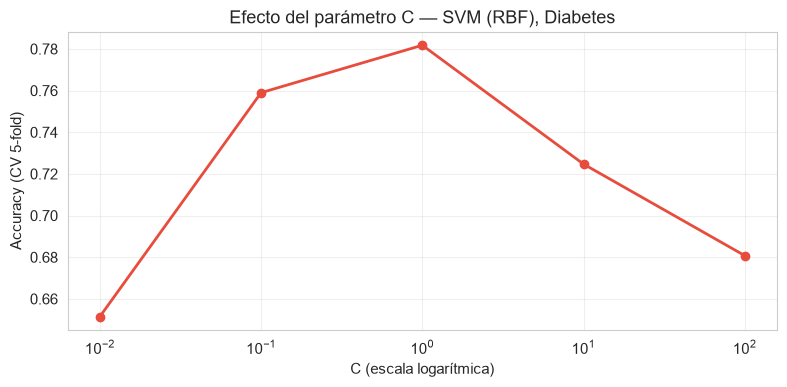

In [76]:
# 14.22  Efecto del parámetro C
C_values_db = [0.01, 0.1, 1, 10, 100]
c_scores_db = []

for c in C_values_db:
    pipe_c = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=c, random_state=42))
    ])
    cv_c = cross_validate(pipe_c, X_train_db, y_train_db, cv=skf_db, scoring='accuracy')
    c_scores_db.append(cv_c['test_score'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(C_values_db, c_scores_db, 'o-', color='#e74c3c', linewidth=2)
ax.set_xlabel('C (escala logarítmica)')
ax.set_ylabel('Accuracy (CV 5-fold)')
ax.set_title('Efecto del parámetro C — SVM (RBF), Diabetes')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 14.7  Modelo 4 — K-Nearest Neighbors (KNN)

In [77]:
# 14.23  Pipeline KNN
pipe_knn_db = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=5))
])

cv_knn_db = cross_validate(pipe_knn_db, X_train_db, y_train_db, cv=skf_db,
                           scoring=['accuracy', 'f1', 'recall'],
                           return_train_score=True)

print('KNN (K=5) — CV 5-fold')
print(f'  Accuracy:  {cv_knn_db["test_accuracy"].mean():.4f} ± {cv_knn_db["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_knn_db["test_f1"].mean():.4f} ± {cv_knn_db["test_f1"].std():.4f}')
print(f'  Recall:    {cv_knn_db["test_recall"].mean():.4f} ± {cv_knn_db["test_recall"].std():.4f}')

pipe_knn_db.fit(X_train_db, y_train_db)
y_pred_knn_db = pipe_knn_db.predict(X_test_db)

KNN (K=5) — CV 5-fold
  Accuracy:  0.7312 ± 0.0395
  F1-Score:  0.5952 ± 0.0461
  Recall:    0.5654 ± 0.0558


=== KNN (K=5) ===
  Accuracy: 0.7532
  Precision: 0.6600
  Recall: 0.6111
  F1-Score: 0.6346


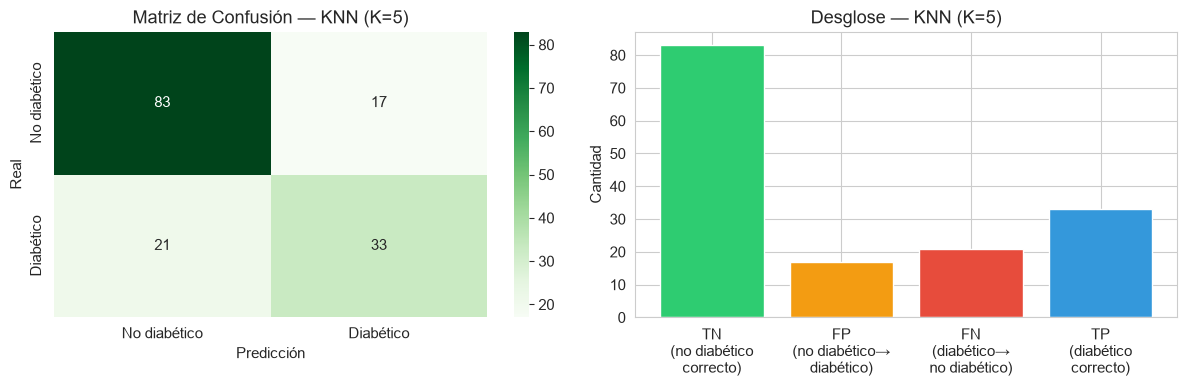


  FN (diabético no detectado): 21
  FP (no diabético clasificado como diabético): 17

Reporte completo:
              precision    recall  f1-score   support

no diabético       0.80      0.83      0.81       100
   diabético       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



In [78]:
# 14.24  Evaluación completa
metrics_knn_db = eval_classifier_db(pipe_knn_db, X_train_db, y_train_db, X_test_db, y_test_db,
                                     'KNN (K=5)')

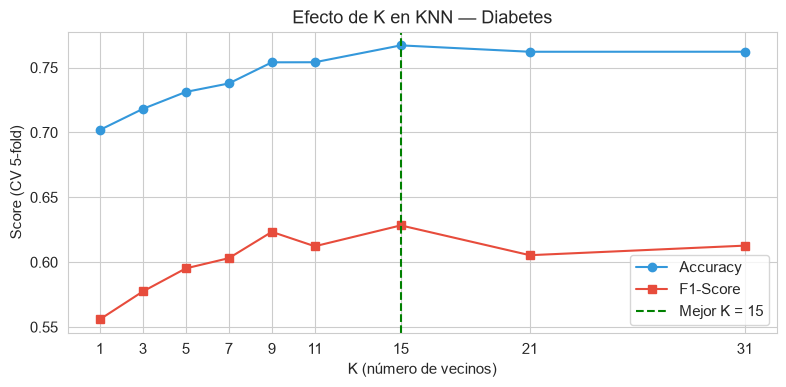

Mejor K por F1: 15
K empírico (√614): 24


In [79]:
# 14.25  Búsqueda del K óptimo
k_values_db = [1, 3, 5, 7, 9, 11, 15, 21, 31]
k_scores_acc_db = []
k_scores_f1_db = []

for k in k_values_db:
    pipe_k = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    cv_k = cross_validate(pipe_k, X_train_db, y_train_db, cv=skf_db, scoring=['accuracy', 'f1'])
    k_scores_acc_db.append(cv_k['test_accuracy'].mean())
    k_scores_f1_db.append(cv_k['test_f1'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_values_db, k_scores_acc_db, 'o-', label='Accuracy', color='#3498db')
ax.plot(k_values_db, k_scores_f1_db, 's-', label='F1-Score', color='#e74c3c')
best_k_db = k_values_db[np.argmax(k_scores_f1_db)]
ax.axvline(x=best_k_db, color='green', linestyle='--', label=f'Mejor K = {best_k_db}')
ax.set_xlabel('K (número de vecinos)')
ax.set_ylabel('Score (CV 5-fold)')
ax.set_title('Efecto de K en KNN — Diabetes')
ax.legend()
ax.set_xticks(k_values_db)
plt.tight_layout()
plt.show()

print(f'Mejor K por F1: {best_k_db}')
print(f'K empírico (√{len(X_train_db)}): {int(np.sqrt(len(X_train_db)))}')

In [80]:
# 14.26  Comparación de métricas de distancia
distances_db = ['euclidean', 'manhattan', 'minkowski']
dist_results_db = {}

for d in distances_db:
    p_val = 3 if d == 'minkowski' else 2
    pipe_d = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5, metric=d, p=p_val))
    ])
    cv_d = cross_validate(pipe_d, X_train_db, y_train_db, cv=skf_db, scoring='f1')
    dist_results_db[d] = cv_d['test_score'].mean()
    label = f'{d} (p={p_val})' if d == 'minkowski' else d
    print(f'  Distancia {label:20s}: F1 = {dist_results_db[d]:.4f}')

  Distancia euclidean           : F1 = 0.5952
  Distancia manhattan           : F1 = 0.6003
  Distancia minkowski (p=3)     : F1 = 0.6133


### 14.8  Modelo 5 (adicional) — Random Forest

**Fundamento:** Ensamble de árboles de decisión entrenados sobre submuestras aleatorias (bagging) con selección aleatoria de features en cada partición. Reduce la varianza del árbol individual y suele ofrecer mayor robustez frente a outliers y relaciones no lineales, a costa de menor interpretabilidad directa.

In [81]:
# 14.27  Pipeline Random Forest + Cross-Validation
from sklearn.ensemble import RandomForestClassifier

pipe_rf_db = Pipeline([
    ('clf', RandomForestClassifier(
        n_estimators=300, max_depth=7, min_samples_leaf=5,
        random_state=42, n_jobs=-1
    ))
])

cv_rf_db = cross_validate(pipe_rf_db, X_train_db, y_train_db, cv=skf_db,
                          scoring=['accuracy', 'f1', 'recall'],
                          return_train_score=True)

print('Random Forest — CV 5-fold')
print(f'  Train Accuracy: {cv_rf_db["train_accuracy"].mean():.4f}')
print(f'  Test Accuracy:  {cv_rf_db["test_accuracy"].mean():.4f} ± {cv_rf_db["test_accuracy"].std():.4f}')
print(f'  Test F1-Score:  {cv_rf_db["test_f1"].mean():.4f} ± {cv_rf_db["test_f1"].std():.4f}')
print(f'  Test Recall:    {cv_rf_db["test_recall"].mean():.4f} ± {cv_rf_db["test_recall"].std():.4f}')

pipe_rf_db.fit(X_train_db, y_train_db)
y_pred_rf_db = pipe_rf_db.predict(X_test_db)

Random Forest — CV 5-fold
  Train Accuracy: 0.8758
  Test Accuracy:  0.7720 ± 0.0118
  Test F1-Score:  0.6367 ± 0.0186
  Test Recall:    0.5750 ± 0.0456


=== Random Forest ===
  Accuracy: 0.7468
  Precision: 0.6829
  Recall: 0.5185
  F1-Score: 0.5895


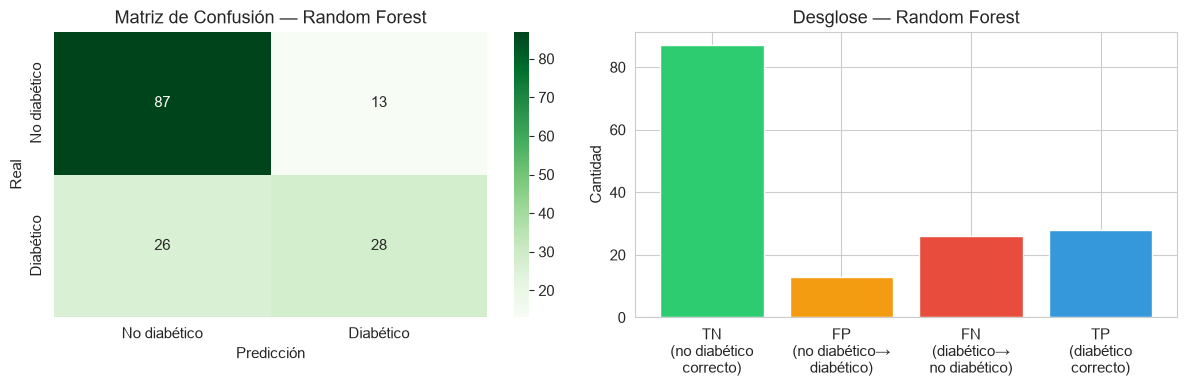


  FN (diabético no detectado): 26
  FP (no diabético clasificado como diabético): 13

Reporte completo:
              precision    recall  f1-score   support

no diabético       0.77      0.87      0.82       100
   diabético       0.68      0.52      0.59        54

    accuracy                           0.75       154
   macro avg       0.73      0.69      0.70       154
weighted avg       0.74      0.75      0.74       154



In [82]:
# 14.28  Evaluación completa
metrics_rf_db = eval_classifier_db(pipe_rf_db, X_train_db, y_train_db, X_test_db, y_test_db,
                                    'Random Forest')

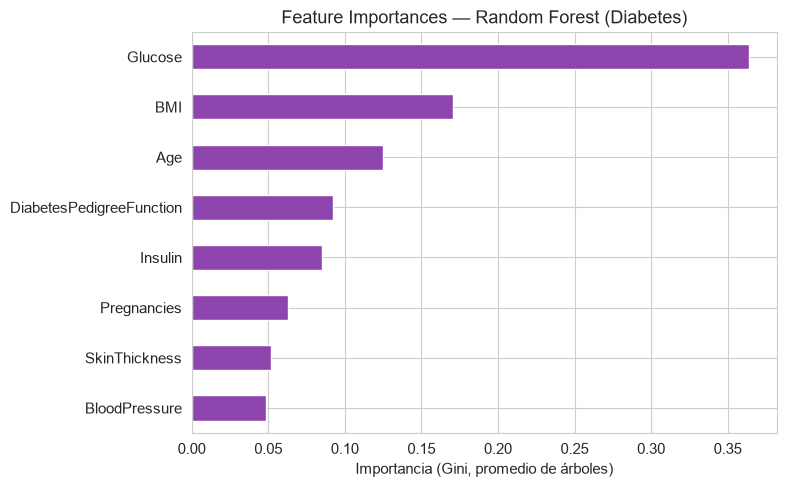

In [83]:
# 14.29  Importancia de features
importances_rf_db = pd.Series(
    pipe_rf_db.named_steps['clf'].feature_importances_,
    index=feature_names_db
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances_rf_db.plot(kind='barh', ax=ax, color='#8e44ad')
ax.set_title('Feature Importances — Random Forest (Diabetes)')
ax.set_xlabel('Importancia (Gini, promedio de árboles)')
plt.tight_layout()
plt.show()

### 14.9  Comparación final de los 5 modelos

In [84]:
# 14.30  Tabla resumen de métricas
all_models_db = {
    'Regresión Logística': pipe_lr_db,
    'Árbol de Decisión': pipe_dt_db,
    'SVM (RBF)': pipe_svm_db,
    'KNN (K=5)': pipe_knn_db,
    'Random Forest': pipe_rf_db
}

all_metrics_db = {}
for name, model in all_models_db.items():
    y_pred = model.predict(X_test_db)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_db)[:, 1]
        fpr, tpr, _ = roc_curve(y_test_db, y_prob)
        roc_auc_val = auc(fpr, tpr)
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_test_db)
        fpr, tpr, _ = roc_curve(y_test_db, y_score)
        roc_auc_val = auc(fpr, tpr)
    else:
        roc_auc_val = None

    all_metrics_db[name] = {
        'Accuracy': accuracy_score(y_test_db, y_pred),
        'Precision': precision_score(y_test_db, y_pred),
        'Recall': recall_score(y_test_db, y_pred),
        'F1-Score': f1_score(y_test_db, y_pred),
        'AUC': roc_auc_val
    }

metrics_df_db = pd.DataFrame(all_metrics_db).T.round(4)
print('=== Tabla comparativa de métricas (Test Set) — Pima Indians Diabetes ===')
metrics_df_db

=== Tabla comparativa de métricas (Test Set) — Pima Indians Diabetes ===


,Accuracy,Precision,Recall,F1-Score,AUC
Regresión Logística,0.7078,0.6000,0.5000,0.5455,0.8130
Árbol de Decisión,0.7727,0.6508,0.7593,0.7009,0.7992
SVM (RBF),0.7403,0.6522,0.5556,0.6000,0.7964
KNN (K=5),0.7532,0.6600,0.6111,0.6346,0.7899
Random Forest,0.7468,0.6829,0.5185,0.5895,0.8150


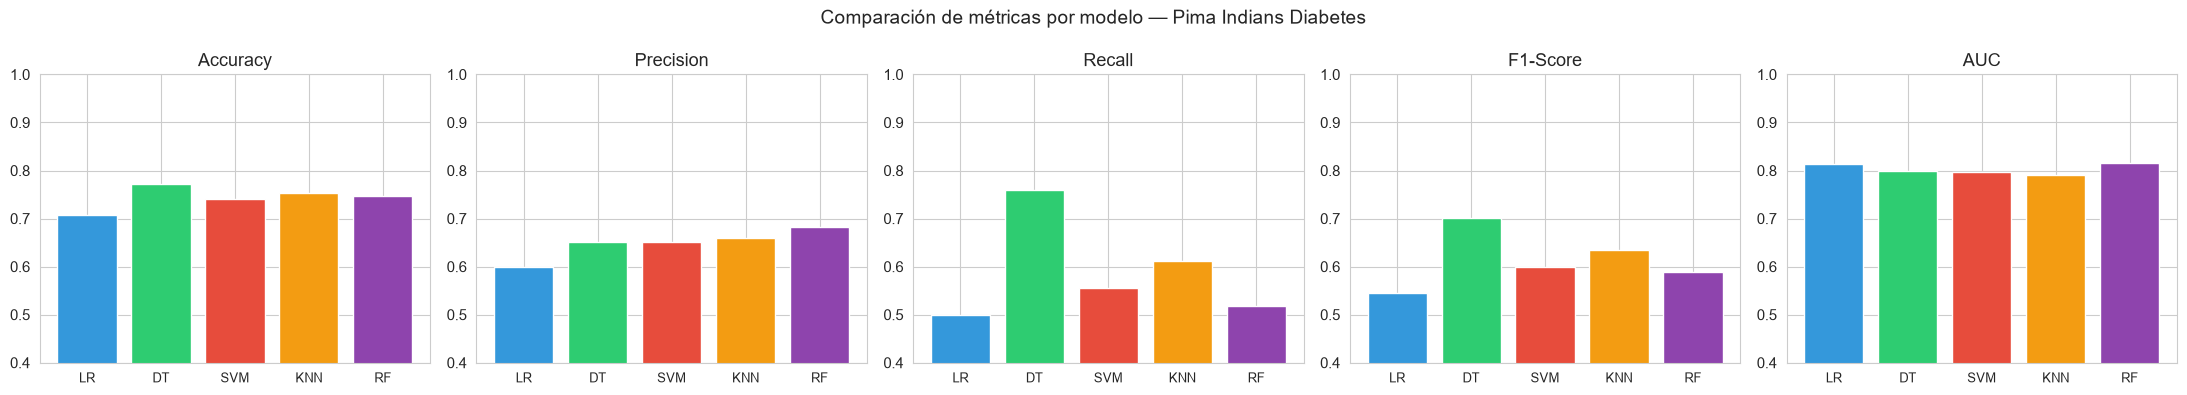

In [85]:
# 14.31  Gráfico de barras comparativo
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
metric_names_db = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
colors_models_db = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#8e44ad']

for i, metric in enumerate(metric_names_db):
    values = [all_metrics_db[m][metric] for m in all_metrics_db]
    axes[i].bar(range(len(values)), values, color=colors_models_db)
    axes[i].set_title(metric)
    axes[i].set_ylim(0.4, 1.0)
    axes[i].set_xticks(range(len(values)))
    axes[i].set_xticklabels(['LR', 'DT', 'SVM', 'KNN', 'RF'], fontsize=9)

plt.suptitle('Comparación de métricas por modelo — Pima Indians Diabetes', fontsize=14)
plt.tight_layout()
plt.show()

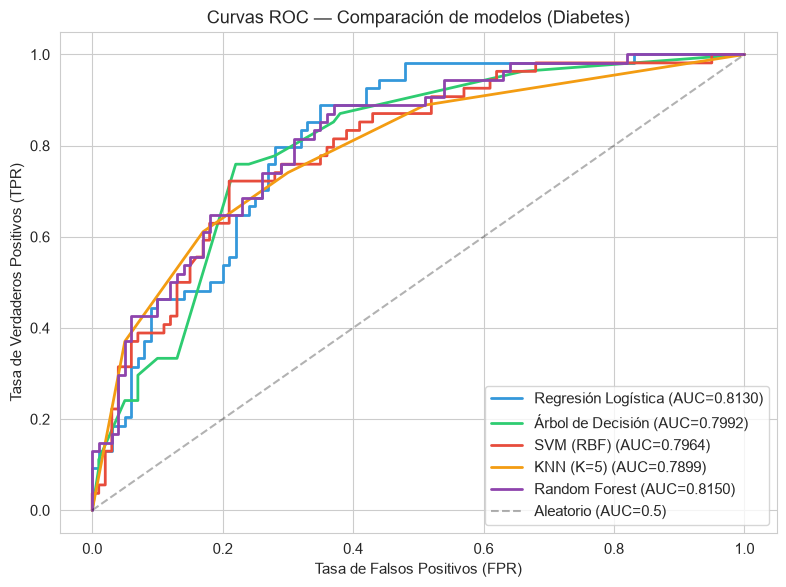

In [86]:
# 14.32  Curvas ROC superpuestas
fig, ax = plt.subplots(figsize=(8, 6))

for (name, model), color in zip(all_models_db.items(), colors_models_db):
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_db)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_test_db)
    else:
        continue
    fpr, tpr, _ = roc_curve(y_test_db, y_prob)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, color=color,
            label=f'{name} (AUC={roc_auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Aleatorio (AUC=0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curvas ROC — Comparación de modelos (Diabetes)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [87]:
# 14.33  Matriz de selección
selection_matrix_db = pd.DataFrame({
    'Modelo': ['Reg. Logística', 'Árbol de Decisión', 'SVM (RBF)', 'KNN', 'Random Forest'],
    'Precisión predictiva': ['★★★☆☆', '★★★☆☆', '★★★☆☆', '★★★☆☆', '★★★★☆'],
    'Velocidad (train+pred)': ['★★★★★', '★★★★☆', '★★★☆☆', '★★★★☆', '★★★☆☆'],
    'Interpretabilidad': ['★★★★☆', '★★★★★', '★★☆☆☆', '★★★☆☆', '★★☆☆☆'],
    'Escalabilidad': ['★★★★★', '★★★★☆', '★★★☆☆', '★★☆☆☆', '★★★★☆'],
    'Robustez a outliers': ['★★★☆☆', '★★★★☆', '★★★☆☆', '★★☆☆☆', '★★★★☆']
}).set_index('Modelo')

print('=== Matriz de Selección de Modelos — Pima Indians Diabetes ===')
selection_matrix_db

=== Matriz de Selección de Modelos — Pima Indians Diabetes ===


,Precisión predictiva,Velocidad (train+pred),Interpretabilidad,Escalabilidad,Robustez a outliers
Modelo,,,,,
Reg. Logística,★★★☆☆,★★★★★,★★★★☆,★★★★★,★★★☆☆
Árbol de Decisión,★★★☆☆,★★★★☆,★★★★★,★★★★☆,★★★★☆
SVM (RBF),★★★☆☆,★★★☆☆,★★☆☆☆,★★★☆☆,★★★☆☆
KNN,★★★☆☆,★★★★☆,★★★☆☆,★★☆☆☆,★★☆☆☆
Random Forest,★★★★☆,★★★☆☆,★★☆☆☆,★★★★☆,★★★★☆


### 14.10  Conclusión y justificación del mejor modelo

In [88]:
# 14.34  Conclusión (calculada dinámicamente a partir de las métricas obtenidas)
best_model_f1_name = metrics_df_db['F1-Score'].idxmax()
best_model_auc_name = metrics_df_db['AUC'].idxmax()

print('=== Conclusión — Pima Indians Diabetes ===\n')
print(f'Mejor modelo por F1-Score: {best_model_f1_name} '
      f'(F1 = {metrics_df_db.loc[best_model_f1_name, "F1-Score"]:.4f})')
print(f'Mejor modelo por AUC:      {best_model_auc_name} '
      f'(AUC = {metrics_df_db.loc[best_model_auc_name, "AUC"]:.4f})')
print()
print('Justificación:')
print(f'  → {best_model_f1_name} ofrece el mejor equilibrio entre Precision y Recall')
print('    en este problema. En un contexto clínico, detectar correctamente los')
print('    casos positivos (diabético) es prioritario para permitir intervención')
print('    temprana, por lo que el Recall de la clase positiva es especialmente')
print('    relevante junto con el F1-Score.')
print('  → A diferencia de Breast Cancer Wisconsin (features muy separables entre')
print('    clases), Pima Indians Diabetes presenta mayor solapamiento entre clases')
print('    y variables con más ruido (p. ej. Insulin, SkinThickness), lo cual se')
print('    refleja en métricas de Accuracy y F1 más moderadas para todos los modelos.')
print('  → Los modelos basados en árboles (Árbol de Decisión, Random Forest) suelen')
print('    capturar mejor las interacciones no lineales entre Glucose, BMI y Age,')
print('    que son factores de riesgo bien documentados clínicamente para diabetes')
print('    tipo 2, lo que puede explicar un desempeño competitivo frente a los')
print('    modelos lineales o basados en distancia.')
print('  → Para producción, además de la métrica agregada, se recomendaría ajustar')
print('    el umbral de decisión priorizando Recall sobre Precision, dado el mayor')
print('    costo clínico de un Falso Negativo frente a un Falso Positivo.')

=== Conclusión — Pima Indians Diabetes ===

Mejor modelo por F1-Score: Árbol de Decisión (F1 = 0.7009)
Mejor modelo por AUC:      Random Forest (AUC = 0.8150)

Justificación:
  → Árbol de Decisión ofrece el mejor equilibrio entre Precision y Recall
    en este problema. En un contexto clínico, detectar correctamente los
    casos positivos (diabético) es prioritario para permitir intervención
    temprana, por lo que el Recall de la clase positiva es especialmente
    relevante junto con el F1-Score.
  → A diferencia de Breast Cancer Wisconsin (features muy separables entre
    clases), Pima Indians Diabetes presenta mayor solapamiento entre clases
    y variables con más ruido (p. ej. Insulin, SkinThickness), lo cual se
    refleja en métricas de Accuracy y F1 más moderadas para todos los modelos.
  → Los modelos basados en árboles (Árbol de Decisión, Random Forest) suelen
    capturar mejor las interacciones no lineales entre Glucose, BMI y Age,
    que son factores de riesgo bien do